# Notebook 04 — Exploratory Data Analysis (EDA)

## Objective

Explore the training data and identify patterns relevant to
feature engineering and model development.

## Analysis

- Data structure
- Missing values
- Numerical variables
- Categorical variables
- Target relationships
- Date and time patterns
- Geography
- Data quality
- Leakage

## Method

- Training data only
- One row per order
- Target: `late`

EDA findings are used to guide Notebook 05.

In [9]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [10]:
TRAIN_PATH = Path("../artifacts/notebook_03/train.parquet")

OUTPUT_DIR = Path("../artifacts/notebook_04")
CHARTS_DIR = OUTPUT_DIR / "charts"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("Training input:", TRAIN_PATH)
print("Output directory:", OUTPUT_DIR)
print("Charts directory:", CHARTS_DIR)

Training input: ..\artifacts\notebook_03\train.parquet
Output directory: ..\artifacts\notebook_04
Charts directory: ..\artifacts\notebook_04\charts


In [11]:
train = pd.read_parquet(TRAIN_PATH)

print(f"Training dataset shape: {train.shape}")
print(f"Number of rows: {len(train):,}")
print(f"Number of columns: {train.shape[1]}")

Training dataset shape: (67532, 22)
Number of rows: 67,532
Number of columns: 22


## Prediction Point

The prediction point is **order approval time**.

Only information available at or before `order_approved_at`
is eligible for predictive features.

Later information is used only for diagnostics and leakage checks.

In [12]:
# Validate the training artifact before any EDA transformations.
assert len(train) == 67_532
assert train["order_id"].is_unique
assert train["late"].notna().all()

# Preserve the original training artifact unchanged.
ORIGINAL_SOURCE_COLUMNS = train.columns.tolist()
eda = train.copy()

print("Basic training-data validation passed.")
print("One row per order: True")
print("All training labels available: True")
print("Unique order_id: True")
print(f"Original source columns: {len(ORIGINAL_SOURCE_COLUMNS)}")


Basic training-data validation passed.
One row per order: True
All training labels available: True
Unique order_id: True
Original source columns: 22


In [13]:
column_info = pd.DataFrame({
    "column": ORIGINAL_SOURCE_COLUMNS,
    "dtype": eda[ORIGINAL_SOURCE_COLUMNS].dtypes.astype(str).values,
    "missing_count": eda[ORIGINAL_SOURCE_COLUMNS].isna().sum().values,
    "missing_pct": (eda[ORIGINAL_SOURCE_COLUMNS].isna().mean() * 100).values,
    "unique_count": eda[ORIGINAL_SOURCE_COLUMNS].nunique(dropna=False).values
})

display(column_info)

column_info.to_csv(
    OUTPUT_DIR / "column_profile.csv",
    index=False
)


,column,dtype,missing_count,missing_pct,unique_count
0,order_id,object,0,0.0000,67532
1,customer_id,object,0,0.0000,67532
2,order_status,object,0,0.0000,2
3,order_purchase_timestamp,datetime64[ns],0,0.0000,67262
4,order_approved_at,datetime64[ns],12,0.0178,63320
5,order_delivered_carrier_date,datetime64[ns],1,0.0015,58354
6,order_delivered_customer_date,datetime64[ns],0,0.0000,67129
7,order_estimated_delivery_date,datetime64[ns],0,0.0000,440
8,customer_city,object,0,0.0000,3668
9,customer_state,object,0,0.0000,27


## Variable Classification

Variables are classified by their semantic role.

Examples:

- `order_id`, `customer_id` → identifiers
- `customer_zip_code_prefix` → geographic code
- `late` → target
- Date columns → temporal
- Price/count columns → numerical
- City/state/status → categorical

In [14]:
ID_COLUMNS = [
    "order_id",
    "customer_id",
]

TARGET_COLUMN = "late"

LEAKAGE_OR_POST_OUTCOME_COLUMNS = [
    "delivery_delay_days",
    "label_data_available",
    "order_delivered_customer_date",
]

PROCESS_COLUMNS_TO_AUDIT = [
    "order_status",
    "order_delivered_carrier_date",
]

DATE_COLUMNS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_estimated_delivery_date",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
]

CATEGORICAL_COLUMNS = [
    "order_status",
    "customer_city",
    "customer_state",
]

GEOGRAPHIC_COLUMNS = [
    "customer_zip_code_prefix",
]

NUMERICAL_COLUMNS = [
    "item_count",
    "total_price",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "payment_count",
    "total_payment_value",
    "payment_types_count",
]

TEXT_COLUMNS = []

print("ID columns:", ID_COLUMNS)
print("Target:", TARGET_COLUMN)
print("Numerical columns:", NUMERICAL_COLUMNS)
print("Categorical columns:", CATEGORICAL_COLUMNS)
print("Geographic columns:", GEOGRAPHIC_COLUMNS)
print("Date columns:", DATE_COLUMNS)
print("Leakage/post-outcome columns:", LEAKAGE_OR_POST_OUTCOME_COLUMNS)

ID columns: ['order_id', 'customer_id']
Target: late
Numerical columns: ['item_count', 'total_price', 'total_freight_value', 'unique_products', 'unique_sellers', 'payment_count', 'total_payment_value', 'payment_types_count']
Categorical columns: ['order_status', 'customer_city', 'customer_state']
Geographic columns: ['customer_zip_code_prefix']
Date columns: ['order_purchase_timestamp', 'order_approved_at', 'order_estimated_delivery_date', 'order_delivered_carrier_date', 'order_delivered_customer_date']
Leakage/post-outcome columns: ['delivery_delay_days', 'label_data_available', 'order_delivered_customer_date']


In [15]:
all_defined = set(
    ID_COLUMNS
    + [TARGET_COLUMN]
    + LEAKAGE_OR_POST_OUTCOME_COLUMNS
    + PROCESS_COLUMNS_TO_AUDIT
    + DATE_COLUMNS
    + CATEGORICAL_COLUMNS
    + GEOGRAPHIC_COLUMNS
    + NUMERICAL_COLUMNS
    + TEXT_COLUMNS
)

missing_definitions = set(ORIGINAL_SOURCE_COLUMNS) - all_defined
extra_definitions = all_defined - set(ORIGINAL_SOURCE_COLUMNS)

print("Columns not explicitly classified:", missing_definitions)
print("Definitions that are not source columns:", extra_definitions)

assert not missing_definitions


Columns not explicitly classified: set()
Definitions that are not source columns: set()


In [16]:
memory_usage_mb = eda[ORIGINAL_SOURCE_COLUMNS].memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Training memory usage: {memory_usage_mb:.2f} MB")


Training memory usage: 32.55 MB


In [17]:
duplicate_rows = eda.duplicated().sum()
duplicate_orders = eda["order_id"].duplicated().sum()

print(f"Duplicate full rows: {duplicate_rows:,}")
print(f"Duplicate order_id values: {duplicate_orders:,}")

assert duplicate_orders == 0

Duplicate full rows: 0
Duplicate order_id values: 0


In [18]:
missing_summary = (
    eda[ORIGINAL_SOURCE_COLUMNS]
    .isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(eda) * 100
)

missing_summary = (
    missing_summary
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

display(missing_summary)

missing_summary.to_csv(
    OUTPUT_DIR / "missing_values.csv"
)


,missing_count,missing_pct
order_approved_at,12,0.0178
order_delivered_carrier_date,1,0.0015


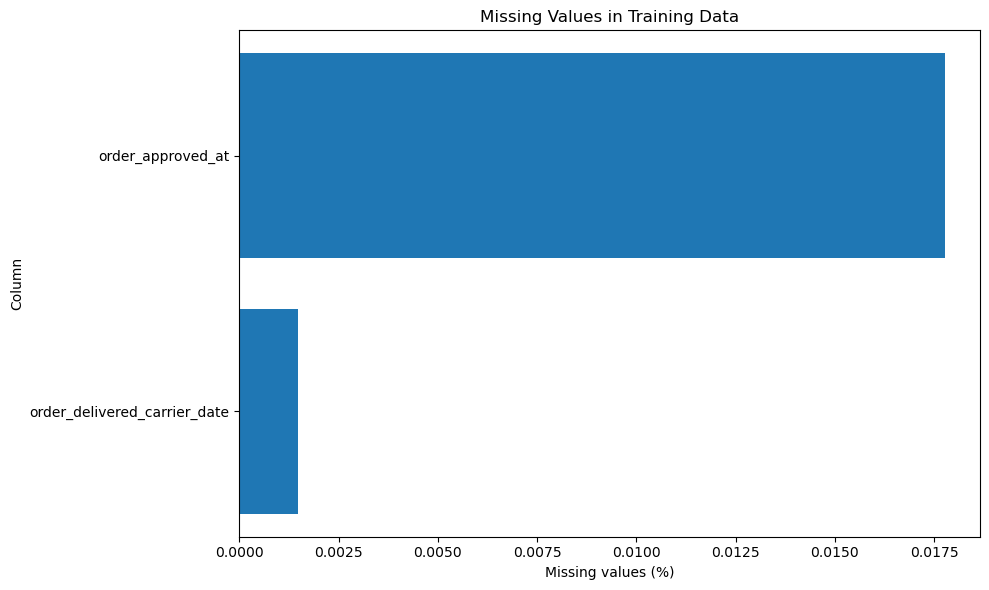

In [19]:
if not missing_summary.empty:
    plt.figure(figsize=(10, 6))

    plt.barh(
        missing_summary.index[::-1],
        missing_summary["missing_pct"][::-1]
    )

    plt.xlabel("Missing values (%)")
    plt.ylabel("Column")
    plt.title("Missing Values in Training Data")
    plt.tight_layout()

    plt.savefig(
        CHARTS_DIR / "missing_values.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

In [20]:
missing_by_target = []

for col in ORIGINAL_SOURCE_COLUMNS:
    if eda[col].isna().any():
        grouped = (
            eda.groupby("late")[col]
            .apply(lambda s: s.isna().mean() * 100)
            .rename("missing_pct")
            .reset_index()
        )

        grouped["column"] = col
        missing_by_target.append(grouped)

if missing_by_target:
    missing_by_target = pd.concat(
        missing_by_target,
        ignore_index=True
    )
else:
    missing_by_target = pd.DataFrame(
        columns=["late", "missing_pct", "column"]
    )

display(missing_by_target)
missing_by_target.to_csv(OUTPUT_DIR / "missing_by_target.csv", index=False)


,late,missing_pct,column
0,0,0.0193,order_approved_at
1,1,0.0000,order_approved_at
2,0,0.0000,order_delivered_carrier_date
3,1,0.0183,order_delivered_carrier_date


In [21]:
# Missingness audit with descriptive status and target context.
missing_audit_rows = []

for col in ORIGINAL_SOURCE_COLUMNS:
    n_missing = int(eda[col].isna().sum())
    if n_missing == 0:
        continue

    row = {
        "column": col,
        "missing_count": n_missing,
        "missing_pct": n_missing / len(eda) * 100,
    }

    if "order_status" in eda.columns:
        status_missing = (
            eda.loc[eda[col].isna(), "order_status"]
            .value_counts(dropna=False)
            .to_dict()
        )
        row["missing_by_order_status"] = str(status_missing)

    row["late_rate_when_missing_pct"] = (
        eda.loc[eda[col].isna(), "late"].mean() * 100
    )
    row["late_rate_when_observed_pct"] = (
        eda.loc[eda[col].notna(), "late"].mean() * 100
    )

    missing_audit_rows.append(row)

missing_audit = pd.DataFrame(missing_audit_rows)
display(missing_audit)
missing_audit.to_csv(OUTPUT_DIR / "missingness_audit.csv", index=False)


,column,missing_count,missing_pct,missing_by_order_status,late_rate_when_missing_pct,late_rate_when_observed_pct
0,order_approved_at,12,0.0178,{'delivered': 12},0.0000,8.1146
1,order_delivered_carrier_date,1,0.0015,{'delivered': 1},100.0000,8.1118


## Missingness

Missing values are analyzed as potential data-quality
or prediction-time availability signals.

We distinguish:

- Structural missingness
- Potentially informative missingness
- Unsafe post-prediction missingness

Missingness is descriptive and does not imply causality.

In [22]:
numeric_summary = eda[NUMERICAL_COLUMNS].describe().T

numeric_summary["skewness"] = eda[NUMERICAL_COLUMNS].skew()

display(numeric_summary)

numeric_summary.to_csv(OUTPUT_DIR / "numeric_summary.csv")


,count,mean,std,min,25%,50%,75%,max,skewness
item_count,"67,532.0000",1.1412,0.5341,1.0000,1.0000,1.0000,1.0000,20.0000,7.1966
total_price,"67,532.0000",137.7047,213.6244,0.8500,45.9000,86.9900,149.9000,"13,440.0000",11.0286
total_freight_value,"67,532.0000",22.8671,22.1703,0.0000,13.8600,17.1900,24.1100,"1,794.9600",14.1840
unique_products,"67,532.0000",1.0380,0.2278,1.0000,1.0000,1.0000,1.0000,8.0000,8.3384
unique_sellers,"67,532.0000",1.0136,0.1219,1.0000,1.0000,1.0000,1.0000,5.0000,9.8662
payment_count,"67,532.0000",1.0430,0.3474,1.0000,1.0000,1.0000,1.0000,22.0000,19.8698
total_payment_value,"67,532.0000",160.6040,223.6065,9.5900,62.0100,105.3800,176.6300,"13,664.0800",10.4284
payment_types_count,"67,532.0000",1.0223,0.1476,1.0000,1.0000,1.0000,1.0000,2.0000,6.4727


In [23]:
non_negative_columns = NUMERICAL_COLUMNS

numeric_validity_rows = []

for col in non_negative_columns:
    s = eda[col]
    numeric_validity_rows.append({
        "column": col,
        "negative_count": int((s.dropna() < 0).sum()),
        "zero_count": int((s == 0).sum()),
        "missing_count": int(s.isna().sum()),
        "min": s.min(),
        "max": s.max(),
        "valid_non_negative": bool((s.dropna() >= 0).all()),
    })

numeric_validity_summary = pd.DataFrame(numeric_validity_rows)
display(numeric_validity_summary)
numeric_validity_summary.to_csv(OUTPUT_DIR / "numeric_validity_summary.csv", index=False)

assert (numeric_validity_summary["negative_count"] == 0).all()

,column,negative_count,zero_count,missing_count,min,max,valid_non_negative
0,item_count,0,0,0,1.0000,20.0000,True
1,total_price,0,0,0,0.8500,"13,440.0000",True
2,total_freight_value,0,227,0,0.0000,"1,794.9600",True
3,unique_products,0,0,0,1.0000,8.0000,True
4,unique_sellers,0,0,0,1.0000,5.0000,True
5,payment_count,0,0,0,1.0000,22.0000,True
6,total_payment_value,0,0,0,9.5900,"13,664.0800",True
7,payment_types_count,0,0,0,1.0000,2.0000,True


In [24]:
zero_summary = pd.DataFrame({
    "zero_count": [
        (eda[col] == 0).sum()
        for col in non_negative_columns
    ]
}, index=non_negative_columns)

zero_summary["zero_pct"] = (
    zero_summary["zero_count"] / len(eda) * 100
)

display(zero_summary)
zero_summary.to_csv(OUTPUT_DIR / "zero_summary.csv")


,zero_count,zero_pct
item_count,0,0.0000
total_price,0,0.0000
total_freight_value,227,0.3361
unique_products,0,0.0000
unique_sellers,0,0.0000
payment_count,0,0.0000
total_payment_value,0,0.0000
payment_types_count,0,0.0000


In [25]:
outlier_rows = []

for col in NUMERICAL_COLUMNS:
    series = eda[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((series < lower) | (series > upper)).sum()

    outlier_rows.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_pct": outlier_count / len(series) * 100
    })

outlier_summary = pd.DataFrame(outlier_rows)

display(outlier_summary)

outlier_summary.to_csv(
    OUTPUT_DIR / "outlier_summary.csv",
    index=False
)

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,item_count,1.0000,1.0000,0.0000,1.0000,1.0000,6700,9.9212
1,total_price,45.9000,149.9000,104.0000,-110.1000,305.9000,5402,7.9992
2,total_freight_value,13.8600,24.1100,10.2500,-1.5150,39.4850,6783,10.0441
3,unique_products,1.0000,1.0000,0.0000,1.0000,1.0000,2192,3.2459
4,unique_sellers,1.0000,1.0000,0.0000,1.0000,1.0000,874,1.2942
5,payment_count,1.0000,1.0000,0.0000,1.0000,1.0000,2005,2.9690
6,total_payment_value,62.0100,176.6300,114.6200,-109.9200,348.5600,5341,7.9088
7,payment_types_count,1.0000,1.0000,0.0000,1.0000,1.0000,1505,2.2286


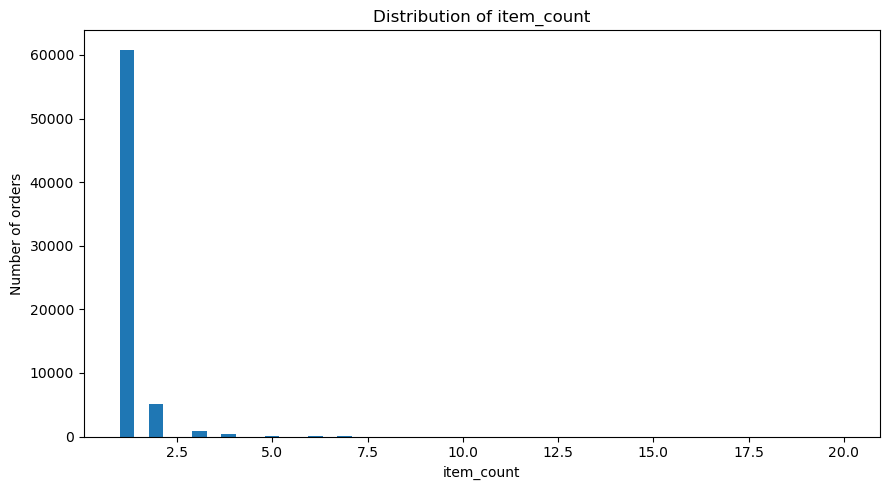

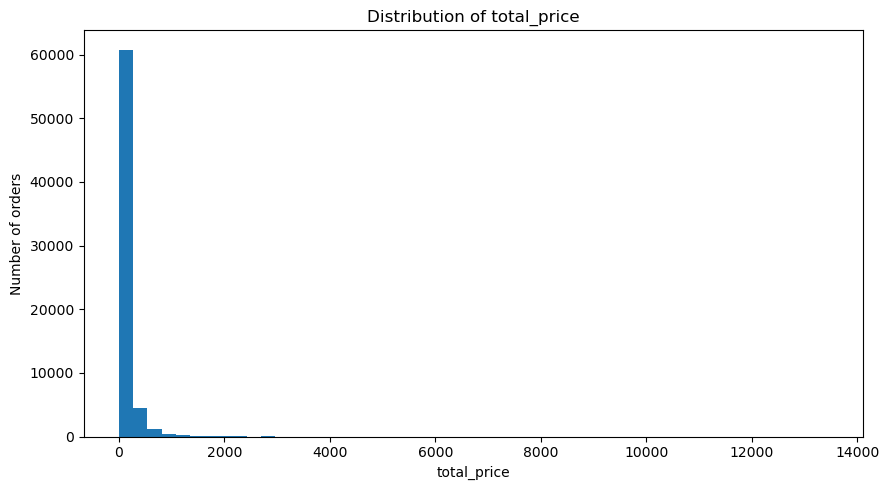

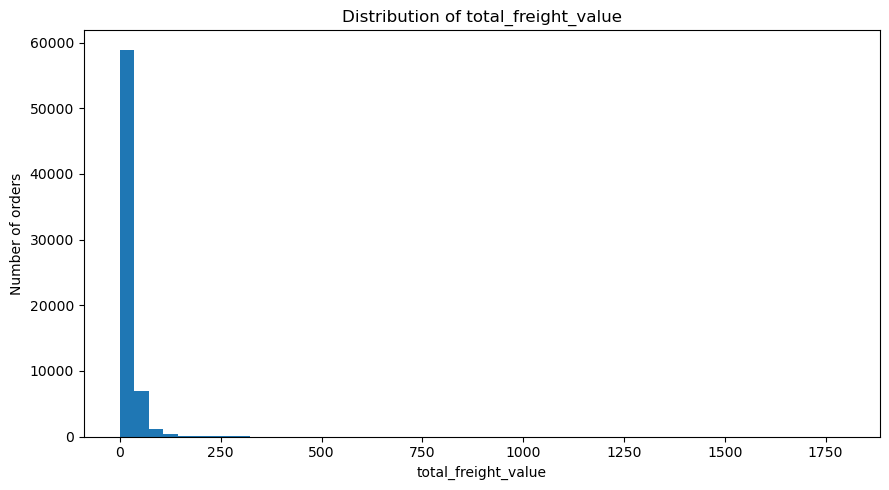

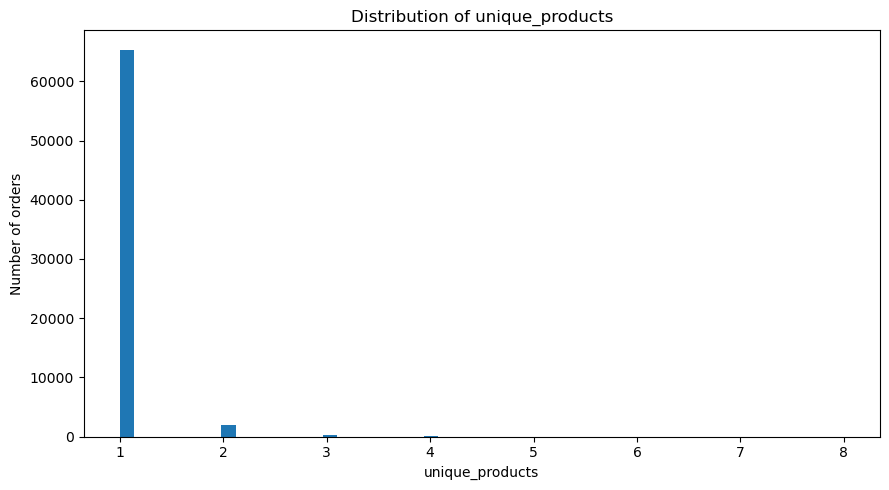

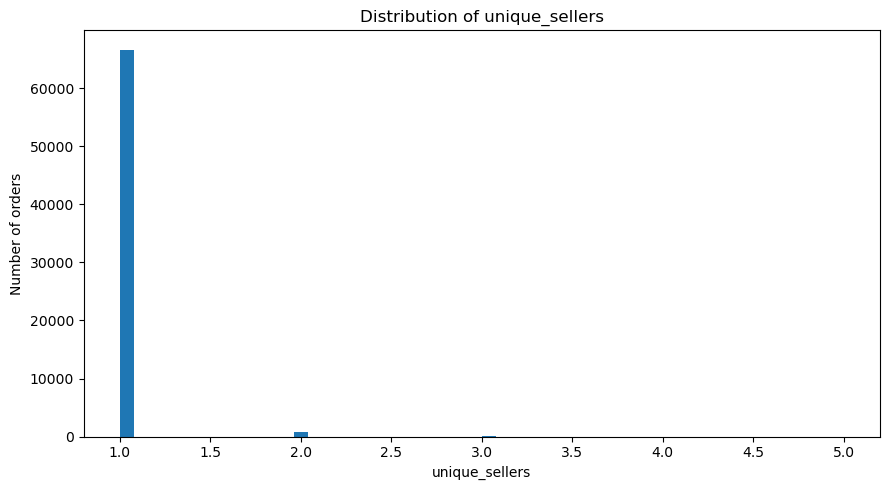

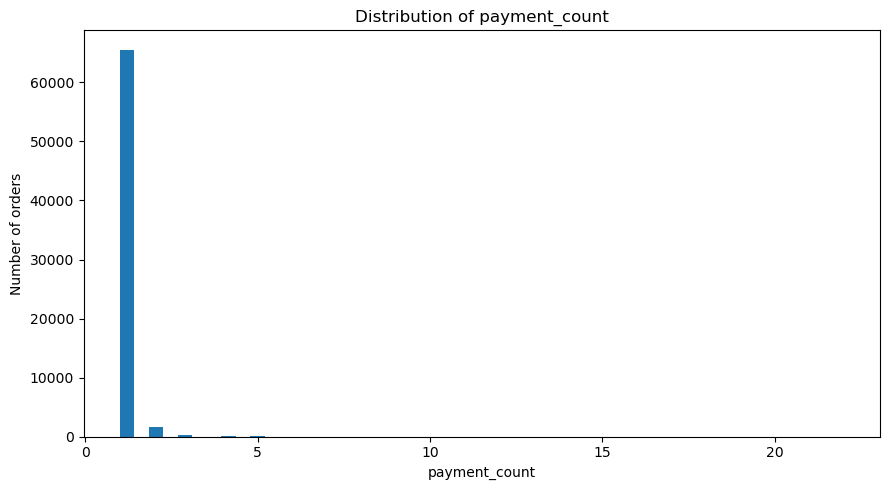

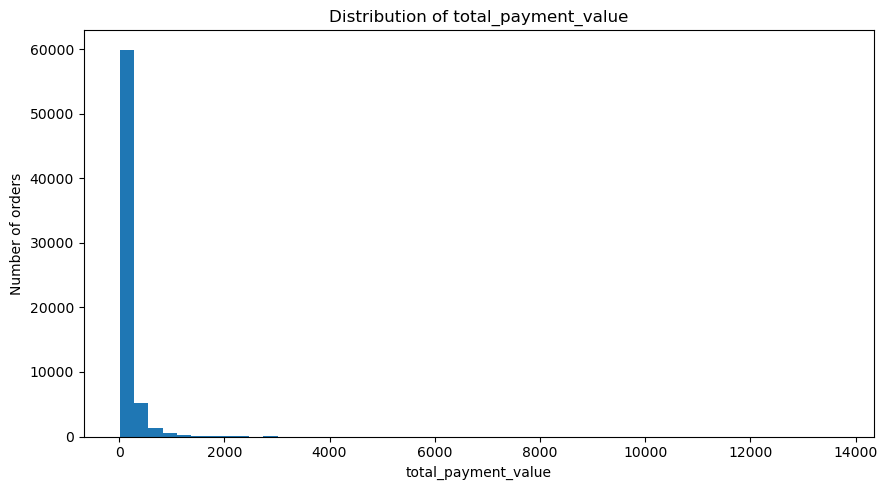

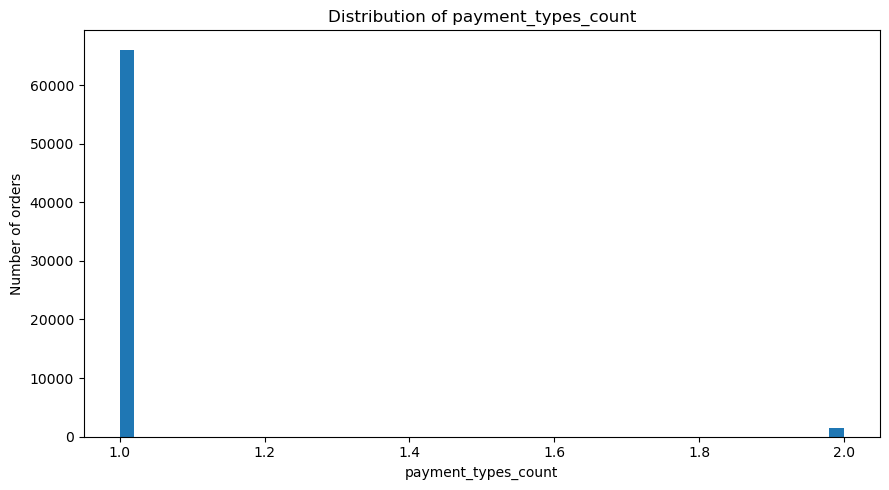

In [26]:
for col in NUMERICAL_COLUMNS:
    plt.figure(figsize=(9, 5))

    plt.hist(
        eda[col].dropna(),
        bins=50
    )

    plt.xlabel(col)
    plt.ylabel("Number of orders")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()

    safe_name = col.replace("/", "_")

    plt.savefig(
        CHARTS_DIR / f"distribution_{safe_name}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

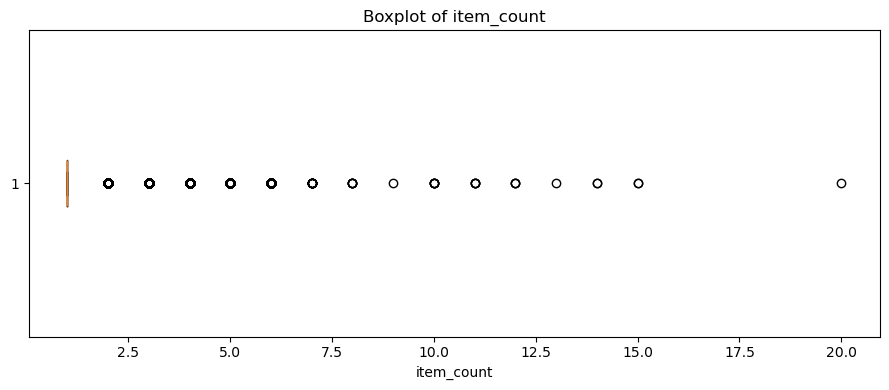

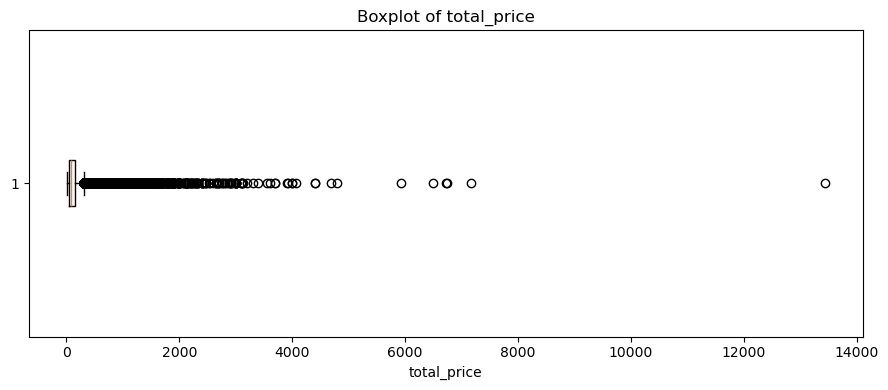

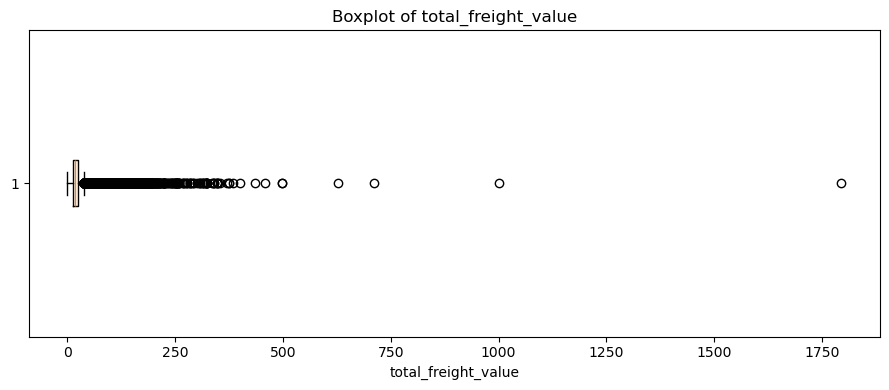

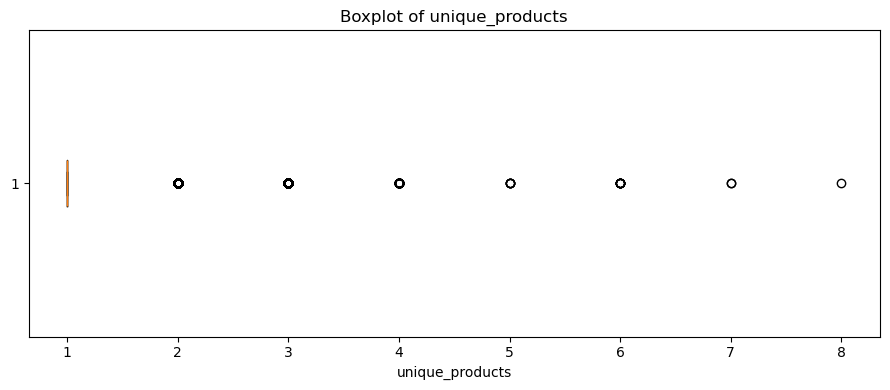

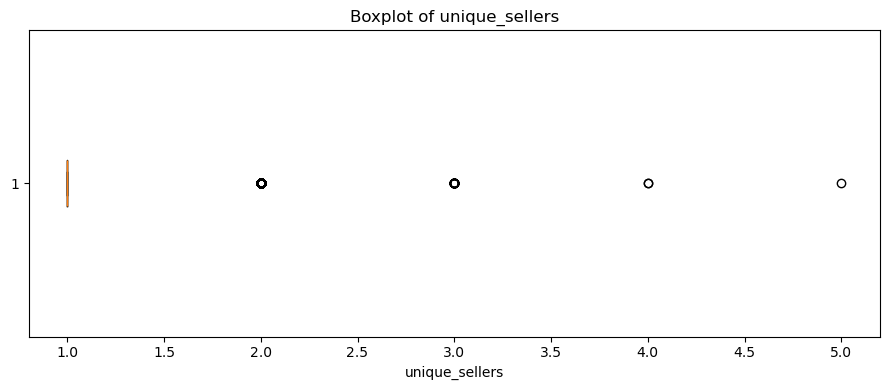

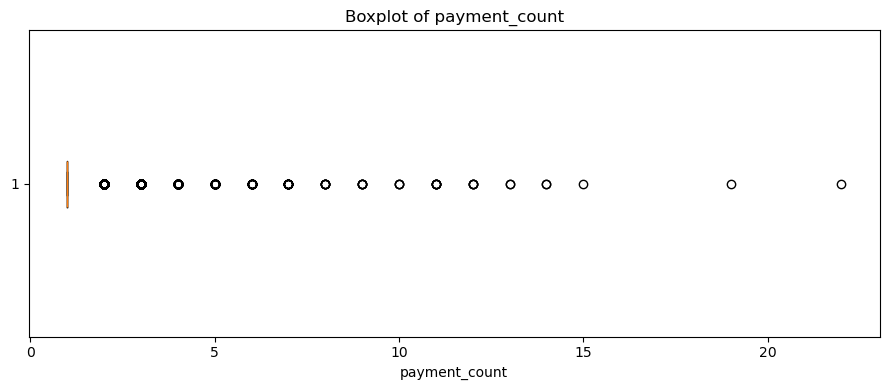

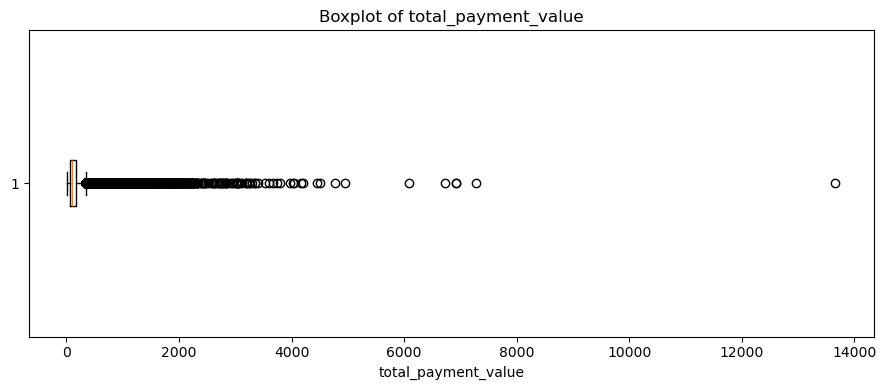

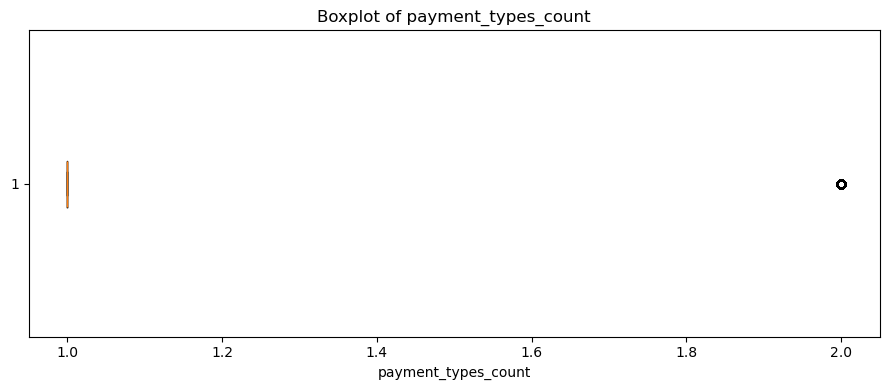

In [27]:
for col in NUMERICAL_COLUMNS:
    plt.figure(figsize=(9, 4))

    plt.boxplot(
        eda[col].dropna(),
        vert=False
    )

    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()

    plt.savefig(
        CHARTS_DIR / f"boxplot_{col}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

## Categorical Variables

Analyze:

- Cardinality
- Category frequency
- Rare categories
- Missing values
- Relationship with `late`

High-cardinality variables require careful encoding.

In [28]:
categorical_profile = []

for col in CATEGORICAL_COLUMNS + GEOGRAPHIC_COLUMNS:
    categorical_profile.append({
        "column": col,
        "unique_values": eda[col].nunique(dropna=True),
        "missing_values": eda[col].isna().sum(),
        "missing_pct": eda[col].isna().mean() * 100
    })

categorical_profile = pd.DataFrame(categorical_profile)

display(categorical_profile)

categorical_profile.to_csv(
    OUTPUT_DIR / "categorical_summary.csv",
    index=False
)

,column,unique_values,missing_values,missing_pct
0,order_status,2,0,0.0000
1,customer_city,3668,0,0.0000
2,customer_state,27,0,0.0000
3,customer_zip_code_prefix,13709,0,0.0000


In [29]:
for col in CATEGORICAL_COLUMNS:
    print(f"\n===== {col} =====")

    counts = (
        eda[col]
        .value_counts(dropna=False)
        .head(20)
    )

    display(counts)


===== order_status =====


order_status
delivered    67527
canceled         5
Name: count, dtype: int64


===== customer_city =====


customer_city
sao paulo                10522
rio de janeiro            4640
belo horizonte            1896
brasilia                  1476
curitiba                  1082
campinas                  1006
porto alegre               945
salvador                   827
guarulhos                  763
sao bernardo do campo      643
niteroi                    573
santo andre                559
santos                     500
osasco                     496
sao jose dos campos        467
goiania                    467
sorocaba                   433
fortaleza                  419
recife                     403
jundiai                    385
Name: count, dtype: int64


===== customer_state =====


customer_state
SP    28316
RJ     8631
MG     7948
RS     3739
PR     3479
SC     2460
BA     2297
DF     1482
ES     1409
GO     1379
PE     1098
CE      878
PA      669
MT      594
MA      513
MS      473
PB      375
PI      346
RN      337
AL      261
Name: count, dtype: int64

In [30]:
RARE_THRESHOLD = 0.005  # 0.5% of rows

rare_summary = []

for col in CATEGORICAL_COLUMNS:
    frequencies = eda[col].value_counts(normalize=True, dropna=False)

    rare_categories = frequencies[frequencies < RARE_THRESHOLD]

    rare_row_count = int(eda[col].isin(rare_categories.index).sum())

    rare_summary.append({
        "column": col,
        "total_categories": len(frequencies),
        "rare_categories": len(rare_categories),
        "rare_percentage_of_categories": (
            len(rare_categories) / len(frequencies) * 100
        ),
        "rare_row_count": rare_row_count,
        "rare_row_percentage": rare_row_count / len(eda) * 100,
        "threshold_pct": RARE_THRESHOLD * 100,
    })

rare_summary = pd.DataFrame(rare_summary)

display(rare_summary)


,column,total_categories,rare_categories,rare_percentage_of_categories,rare_row_count,rare_row_percentage,threshold_pct
0,order_status,2,1,50.0000,5,0.0074,0.5000
1,customer_city,3668,3646,99.4002,38315,56.7361,0.5000
2,customer_state,27,9,33.3333,1446,2.1412,0.5000


In [31]:
rare_summary.to_csv(OUTPUT_DIR / "rare_category_summary.csv", index=False)

In [32]:
# Formatting / duplicated-category audit (detection only; no automatic merging).
def normalize_category(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    value = " ".join(value.split())
    value = "".join(
        ch for ch in unicodedata.normalize("NFKD", value)
        if not unicodedata.combining(ch)
    )
    return value

category_cleaning_audit = []

for col in CATEGORICAL_COLUMNS:
    raw = eda[col].dropna().astype(str)
    normalized = raw.map(normalize_category)

    whitespace_issues = int((raw != raw.str.strip()).sum())

    collision_groups = (
        pd.DataFrame({"raw": raw, "normalized": normalized})
        .groupby("normalized")["raw"]
        .nunique()
    )
    collision_groups = collision_groups[collision_groups > 1]

    has_normalized_collisions = bool(len(collision_groups) > 0)

    category_cleaning_audit.append({
        "column": col,
        "raw_unique": raw.nunique(),
        "normalized_unique": normalized.nunique(),
        "whitespace_issues": whitespace_issues,
        "normalized_collision_groups": int(len(collision_groups)),
        "has_normalized_collisions": has_normalized_collisions,
        "potential_formatting_issue": bool(
            whitespace_issues > 0 or has_normalized_collisions
        ),
    })

category_cleaning_audit = pd.DataFrame(category_cleaning_audit)
display(category_cleaning_audit)
category_cleaning_audit.to_csv(
    OUTPUT_DIR / "categorical_cleaning_audit.csv", index=False
)


,column,raw_unique,normalized_unique,whitespace_issues,normalized_collision_groups,has_normalized_collisions,potential_formatting_issue
0,order_status,2,2,0,0,False,False
1,customer_city,3668,3668,0,0,False,False
2,customer_state,27,27,0,0,False,False


,count,percentage
late,,
0,62053,91.8868
1,5479,8.1132


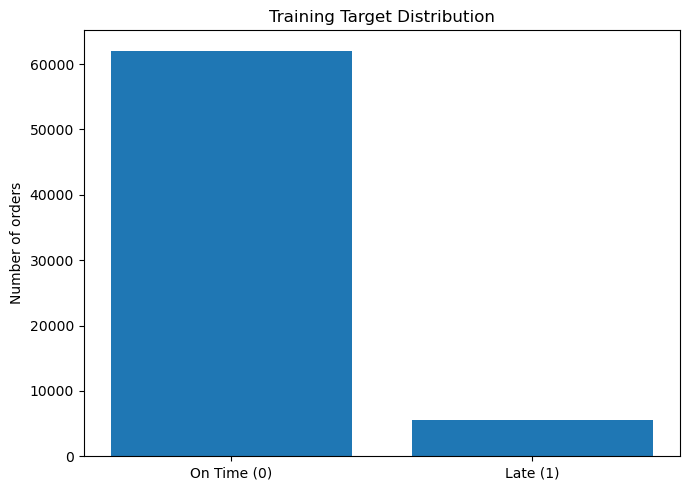

In [33]:
target_counts = eda["late"].value_counts().sort_index()

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": target_counts / len(eda) * 100
})

display(target_distribution)

plt.figure(figsize=(7, 5))

plt.bar(
    ["On Time (0)", "Late (1)"],
    [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ]
)

plt.ylabel("Number of orders")
plt.title("Training Target Distribution")
plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "target_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [34]:
numeric_target_summary = []

for col in NUMERICAL_COLUMNS:
    grouped = (
        eda.groupby("late")[col]
        .agg(["count", "mean", "median", "std"])
    )

    for label in grouped.index:
        numeric_target_summary.append({
            "feature": col,
            "late": int(label),
            "count": grouped.loc[label, "count"],
            "mean": grouped.loc[label, "mean"],
            "median": grouped.loc[label, "median"],
            "std": grouped.loc[label, "std"]
        })

numeric_target_summary = pd.DataFrame(
    numeric_target_summary
)

display(numeric_target_summary)

,feature,late,count,mean,median,std
0,item_count,0,62053,1.1442,1.0000,0.5414
1,item_count,1,5479,1.1071,1.0000,0.4407
2,total_price,0,62053,136.7469,86.2500,212.1132
3,total_price,1,5479,148.5517,89.9000,229.7903
4,total_freight_value,0,62053,22.7111,17.0900,22.0727
5,total_freight_value,1,5479,24.6333,18.1900,23.1763
6,unique_products,0,62053,1.0395,1.0000,0.2335
7,unique_products,1,5479,1.0201,1.0000,0.1491
8,unique_sellers,0,62053,1.0146,1.0000,0.1264
9,unique_sellers,1,5479,1.0022,1.0000,0.0468


In [35]:
mean_comparison = (
    eda.groupby("late")[NUMERICAL_COLUMNS]
    .mean()
    .T
)

mean_comparison.columns = [
    "On_Time_Mean",
    "Late_Mean"
]

mean_comparison["difference"] = (
    mean_comparison["Late_Mean"]
    - mean_comparison["On_Time_Mean"]
)

display(
    mean_comparison.sort_values(
        "difference",
        ascending=False
    )
)

,On_Time_Mean,Late_Mean,difference
total_payment_value,159.4917,173.2018,13.7100
total_price,136.7469,148.5517,11.8048
total_freight_value,22.7111,24.6333,1.9221
payment_types_count,1.0227,1.0175,-0.0052
payment_count,1.0439,1.0329,-0.0111
unique_sellers,1.0146,1.0022,-0.0124
unique_products,1.0395,1.0201,-0.0195
item_count,1.1442,1.1071,-0.0371


<Figure size 800x500 with 0 Axes>

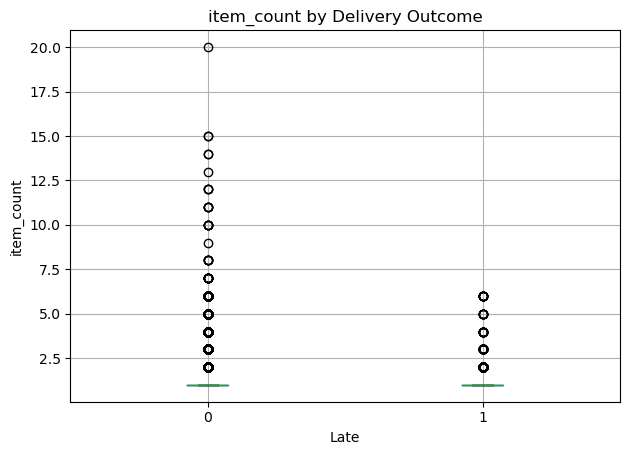

<Figure size 800x500 with 0 Axes>

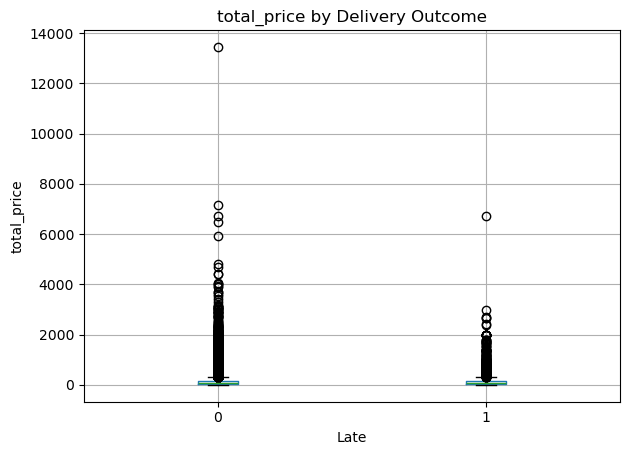

<Figure size 800x500 with 0 Axes>

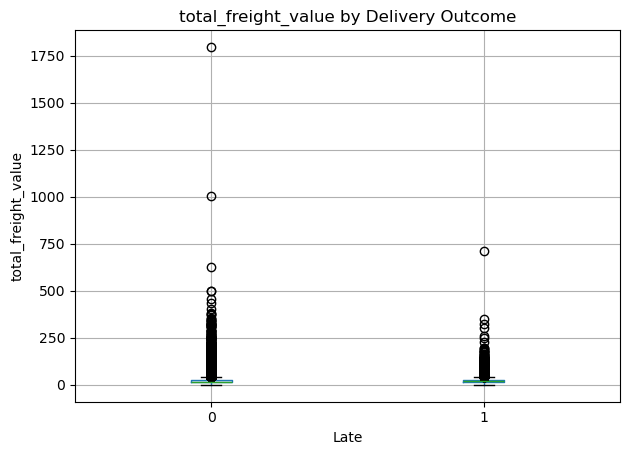

<Figure size 800x500 with 0 Axes>

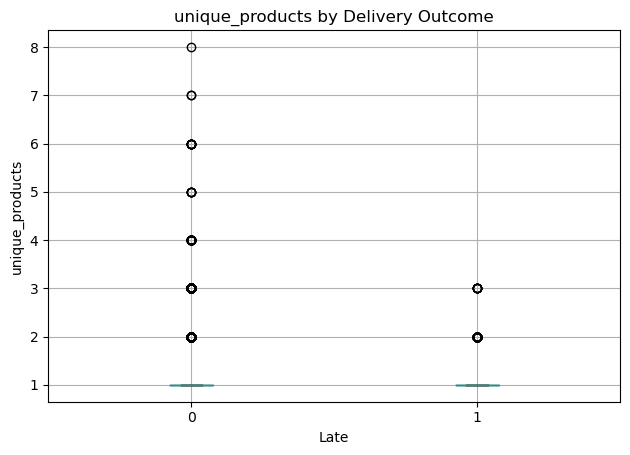

<Figure size 800x500 with 0 Axes>

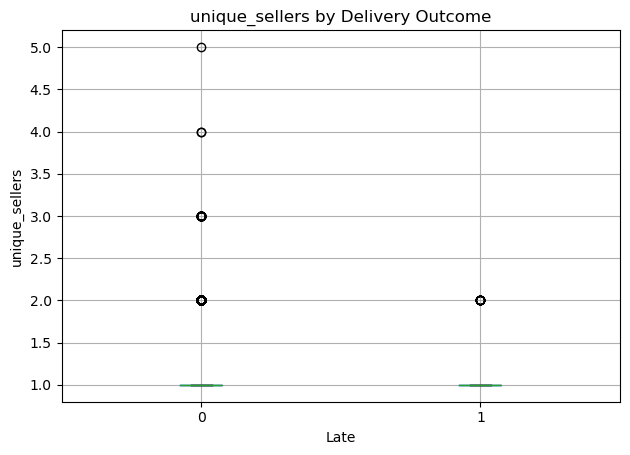

<Figure size 800x500 with 0 Axes>

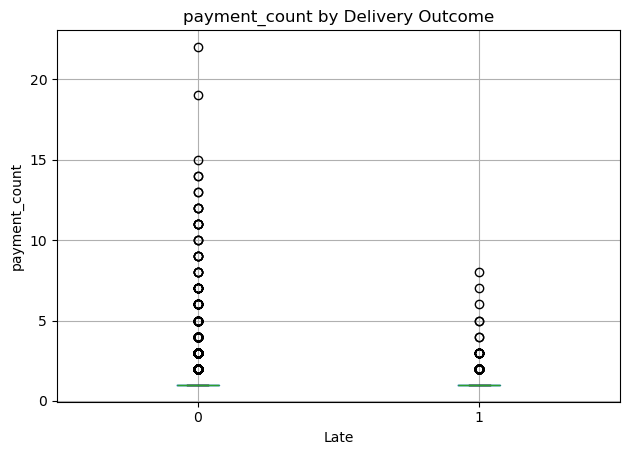

<Figure size 800x500 with 0 Axes>

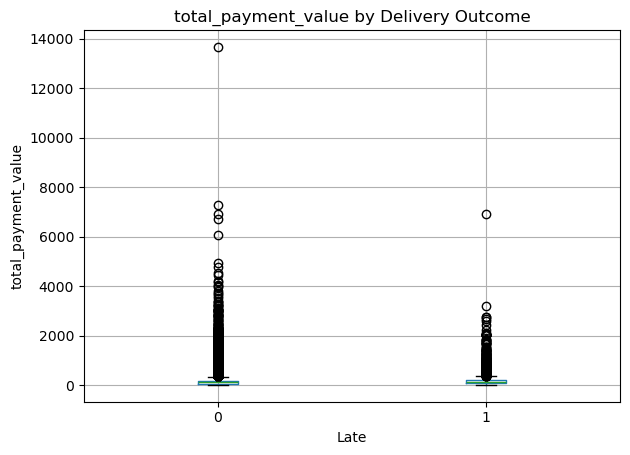

<Figure size 800x500 with 0 Axes>

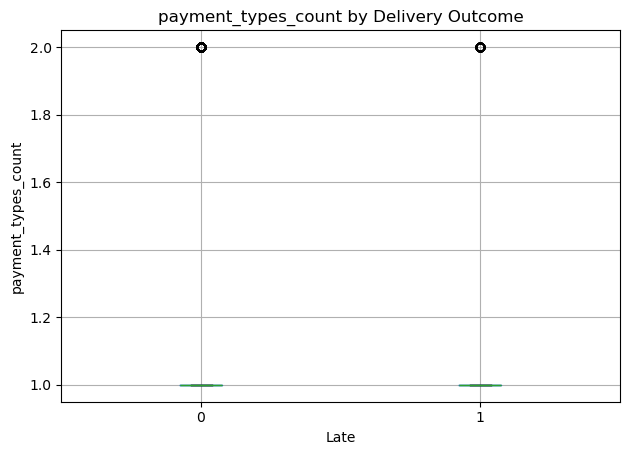

In [36]:
for col in NUMERICAL_COLUMNS:
    plt.figure(figsize=(8, 5))

    eda.boxplot(
        column=col,
        by="late"
    )

    plt.suptitle("")
    plt.title(f"{col} by Delivery Outcome")
    plt.xlabel("Late")
    plt.ylabel(col)
    plt.tight_layout()

    plt.savefig(
        CHARTS_DIR / f"target_boxplot_{col}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

In [37]:
categorical_target_tables = {}
categorical_target_rows = []

for col in CATEGORICAL_COLUMNS:
    table = pd.crosstab(
        eda[col],
        eda["late"],
        normalize="index"
    ) * 100

    table.columns = [
        f"late_{int(c)}_pct"
        for c in table.columns
    ]

    categorical_target_tables[col] = table

    table_reset = table.reset_index()
    table_reset.insert(0, "feature", col)
    categorical_target_rows.append(table_reset)

    print(f"\n===== {col} =====")
    display(table.sort_values("late_1_pct", ascending=False).head(20))

# Long-format artifact for reproducible downstream inspection.
categorical_target_rates = pd.concat(
    categorical_target_rows,
    ignore_index=True,
    sort=False
)

display(categorical_target_rates.head(30))
categorical_target_rates.to_csv(
    OUTPUT_DIR / "categorical_target_rates.csv",
    index=False
)



===== order_status =====


,late_0_pct,late_1_pct
order_status,,
canceled,80.0000,20.0000
delivered,91.8877,8.1123



===== customer_city =====


,late_0_pct,late_1_pct
customer_city,,
pedra lavrada,0.0000,100.0000
arace,0.0000,100.0000
conde,0.0000,100.0000
santo antonio do canaa,0.0000,100.0000
antonio martins,0.0000,100.0000
antonio pereira,0.0000,100.0000
conceicao da ibitipoca,0.0000,100.0000
jacuipe,0.0000,100.0000
apora,0.0000,100.0000



===== customer_state =====


,late_0_pct,late_1_pct
customer_state,,
AL,74.7126,25.2874
MA,80.7018,19.2982
RR,83.3333,16.6667
PI,84.1040,15.8960
CE,84.1686,15.8314
SE,86.1224,13.8776
RJ,86.2820,13.7180
BA,86.4606,13.5394
ES,87.5089,12.4911


,feature,order_status,late_0_pct,late_1_pct,customer_city,customer_state
0,order_status,canceled,80.0000,20.0000,NaN,NaN
1,order_status,delivered,91.8877,8.1123,NaN,NaN
2,customer_city,NaN,100.0000,0.0000,abadia dos dourados,NaN
3,customer_city,NaN,100.0000,0.0000,abadiania,NaN
4,customer_city,NaN,91.6667,8.3333,abaete,NaN
5,customer_city,NaN,66.6667,33.3333,abaetetuba,NaN
6,customer_city,NaN,50.0000,50.0000,abaiara,NaN
7,customer_city,NaN,100.0000,0.0000,abaira,NaN
8,customer_city,NaN,100.0000,0.0000,abare,NaN
9,customer_city,NaN,100.0000,0.0000,abatia,NaN


In [38]:
state_late_rate = (
    eda.groupby("customer_state")["late"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

state_late_rate["late_percentage"] = (
    state_late_rate["mean"] * 100
)

display(state_late_rate)
state_late_rate.to_csv(OUTPUT_DIR / "state_late_rate.csv")


,count,mean,late_percentage
customer_state,,,
AL,261,0.2529,25.2874
MA,513,0.1930,19.2982
RR,30,0.1667,16.6667
PI,346,0.1590,15.8960
CE,878,0.1583,15.8314
SE,245,0.1388,13.8776
RJ,8631,0.1372,13.7180
BA,2297,0.1354,13.5394
ES,1409,0.1249,12.4911


In [39]:
MIN_STATE_ORDERS = 100

state_late_rate_filtered = (
    state_late_rate[
        state_late_rate["count"] >= MIN_STATE_ORDERS
    ]
)

display(state_late_rate_filtered)

,count,mean,late_percentage
customer_state,,,
AL,261,0.2529,25.2874
MA,513,0.1930,19.2982
PI,346,0.1590,15.8960
CE,878,0.1583,15.8314
SE,245,0.1388,13.8776
RJ,8631,0.1372,13.7180
BA,2297,0.1354,13.5394
ES,1409,0.1249,12.4911
PA,669,0.1241,12.4066


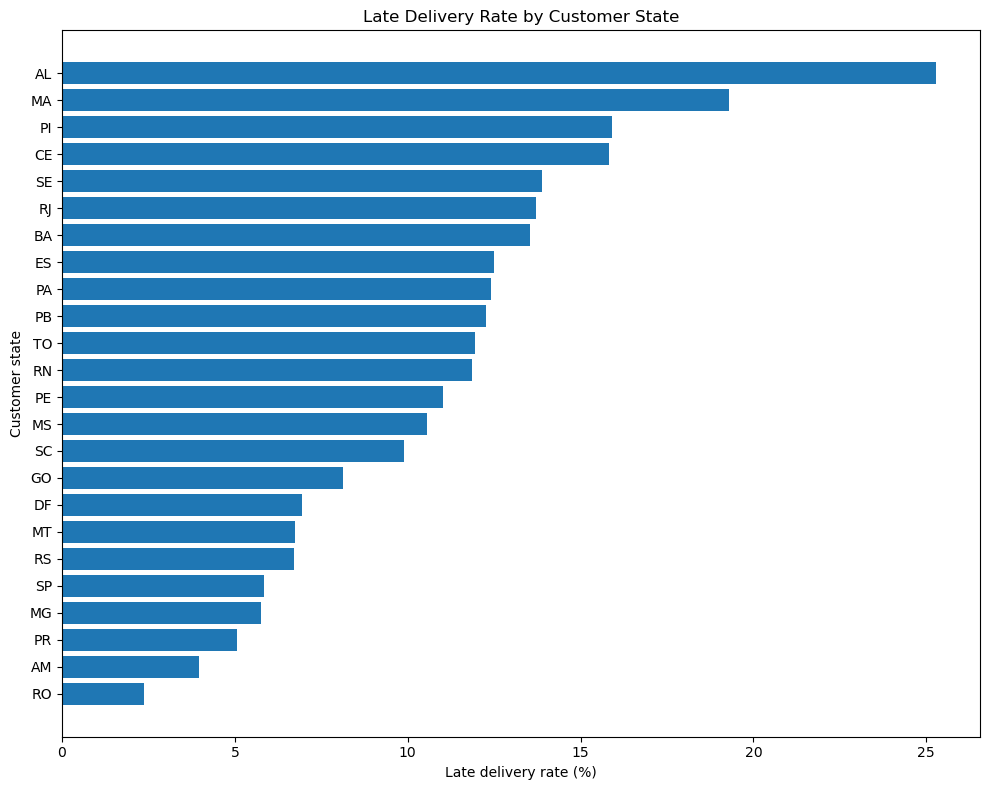

In [40]:
plot_data = (
    state_late_rate_filtered
    .sort_values("late_percentage", ascending=True)
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_data.index,
    plot_data["late_percentage"]
)

plt.xlabel("Late delivery rate (%)")
plt.ylabel("Customer state")
plt.title("Late Delivery Rate by Customer State")
plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "late_rate_by_customer_state.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Geography Limitation

The current order-level artifact contains:

- Customer city
- Customer state
- Customer ZIP-code prefix

Seller geography and customer-seller distance are not available
in this artifact.

They are not reconstructed here to avoid breaking the one-row-per-order
design or introducing unsupported features.

In [41]:
zip_profile = eda["customer_zip_code_prefix"].describe()

display(zip_profile)

zip_unique = eda["customer_zip_code_prefix"].nunique()

print(
    f"Unique customer ZIP-code prefixes: {zip_unique:,}"
)

count     67532
unique    13709
top       22790
freq         99
Name: customer_zip_code_prefix, dtype: object

Unique customer ZIP-code prefixes: 13,709


In [42]:
zip_counts = (
    eda["customer_zip_code_prefix"]
    .value_counts(dropna=False)
)

display(zip_counts.head(20))

customer_zip_code_prefix
22790    99
22793    81
24230    79
29101    77
24220    77
22775    76
35162    72
13212    65
22631    62
11065    59
38400    58
13214    58
37200    58
20540    56
35500    55
38600    52
36900    52
11030    51
07600    50
38408    50
Name: count, dtype: int64

### ZIP-code Interpretation

`customer_zip_code_prefix` is treated as a geographic code,
not a continuous numerical variable.

Therefore, arithmetic correlation is not used.

## Date and Time Analysis

### Predictive-time information

- Order purchase timestamp
- Order approval timestamp
- Estimated delivery date

### Outcome information

- Carrier delivery timestamp
- Actual delivery timestamp
- Delivery delay

Outcome information is used only for diagnostics and leakage analysis.

In [43]:
for col in DATE_COLUMNS:
    eda[col] = pd.to_datetime(
        eda[col],
        errors="coerce"
    )

print(eda[DATE_COLUMNS].dtypes)


order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
dtype: object


In [44]:
purchase_min = eda["order_purchase_timestamp"].min()
purchase_max = eda["order_purchase_timestamp"].max()

print("Training purchase date range:")
print("Minimum:", purchase_min)
print("Maximum:", purchase_max)

Training purchase date range:
Minimum: 2016-10-03 09:44:50
Maximum: 2018-08-29 15:00:37


In [45]:
# Validate chronological order only where the required dates are observed.
def temporal_check(earlier_col, later_col):
    mask = eda[earlier_col].notna() & eda[later_col].notna()
    invalid = int((eda.loc[mask, earlier_col] > eda.loc[mask, later_col]).sum())
    return {
        "comparison": f"{earlier_col} <= {later_col}",
        "comparable_rows": int(mask.sum()),
        "invalid_rows": invalid,
        "invalid_pct_of_comparable": invalid / mask.sum() * 100 if mask.sum() else np.nan,
    }

date_order_checks = pd.DataFrame([
    temporal_check("order_purchase_timestamp", "order_approved_at"),
    temporal_check("order_approved_at", "order_delivered_carrier_date"),
    temporal_check("order_delivered_carrier_date", "order_delivered_customer_date"),
    temporal_check("order_purchase_timestamp", "order_delivered_customer_date"),
])

display(date_order_checks)
date_order_checks.to_csv(OUTPUT_DIR / "date_consistency_checks.csv", index=False)

,comparison,comparable_rows,invalid_rows,invalid_pct_of_comparable
0,order_purchase_timestamp <= order_approved_at,67520,0,0.0000
1,order_approved_at <= order_delivered_carrier_date,67519,938,1.3892
2,order_delivered_carrier_date <= order_delivere...,67531,20,0.0296
3,order_purchase_timestamp <= order_delivered_cu...,67532,0,0.0000


In [46]:
purchase = eda["order_purchase_timestamp"]

eda["eda_purchase_year"] = purchase.dt.year
eda["eda_purchase_month"] = purchase.dt.month
eda["eda_purchase_year_month"] = purchase.dt.to_period("M").astype("string")
eda["eda_purchase_dayofweek"] = purchase.dt.dayofweek
eda["eda_purchase_hour"] = purchase.dt.hour
eda["eda_purchase_weekend"] = purchase.dt.dayofweek >= 5

eda["eda_estimated_lead_days"] = (
    (
        eda["order_estimated_delivery_date"]
        - eda["order_purchase_timestamp"]
    ).dt.total_seconds()
    / 86400
)

eda["eda_approval_delay_hours"] = (
    (
        eda["order_approved_at"]
        - eda["order_purchase_timestamp"]
    ).dt.total_seconds()
    / 3600
)

display(
    eda[
        [
            "eda_purchase_year",
            "eda_purchase_month",
            "eda_purchase_year_month",
            "eda_purchase_dayofweek",
            "eda_purchase_hour",
            "eda_purchase_weekend",
            "eda_estimated_lead_days",
            "eda_approval_delay_hours"
        ]
    ].head()
)


,eda_purchase_year,eda_purchase_month,eda_purchase_year_month,eda_purchase_dayofweek,eda_purchase_hour,eda_purchase_weekend,eda_estimated_lead_days,eda_approval_delay_hours
0,2018,4,2018-04,1,0,False,55.9709,0.2253
1,2018,6,2018-06,0,23,False,23.0130,0.1506
2,2018,7,2018-07,0,20,False,27.1528,0.1836
3,2018,4,2018-04,2,16,False,28.3312,0.4225
4,2018,8,2018-08,2,21,False,6.1115,0.1803


In [47]:
monthly_late_rate = (
    eda.groupby("eda_purchase_month")["late"]
    .agg(["count", "mean"])
)

monthly_late_rate["late_percentage"] = (
    monthly_late_rate["mean"] * 100
)

display(monthly_late_rate)


,count,mean,late_percentage
eda_purchase_month,,,
1,5447,0.0633,6.3338
2,5807,0.1354,13.5354
3,6653,0.1709,17.0900
4,6353,0.0601,6.0129
5,7176,0.0680,6.8004
6,6490,0.0223,2.2342
7,7074,0.0409,4.0854
8,7379,0.0759,7.5891
9,2863,0.0580,5.7981


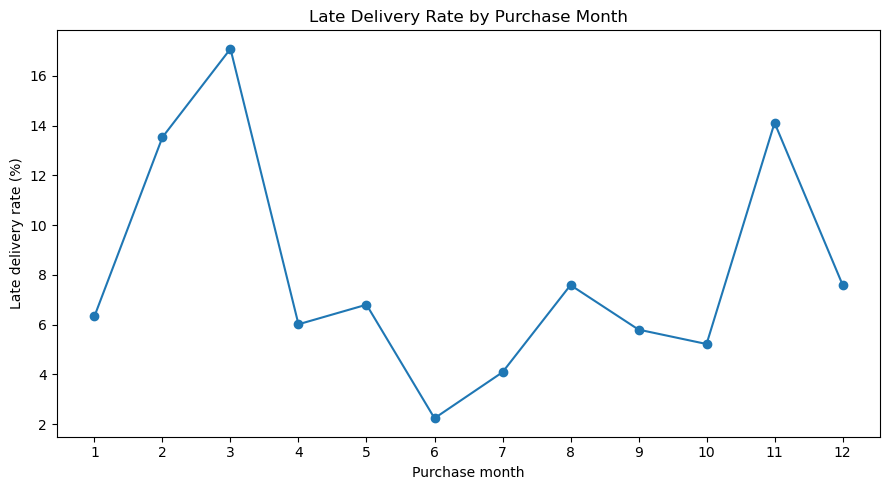

In [48]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_late_rate.index,
    monthly_late_rate["late_percentage"],
    marker="o"
)

plt.xlabel("Purchase month")
plt.ylabel("Late delivery rate (%)")
plt.title("Late Delivery Rate by Purchase Month")
plt.xticks(range(1, 13))
plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "late_rate_by_month.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

,count,mean,late_percentage
eda_purchase_year_month,,,
2016-10,193,0.0155,1.5544
2017-01,536,0.0243,2.4254
2017-02,1177,0.0348,3.4834
2017-03,1753,0.0525,5.2481
2017-04,1605,0.0791,7.9128
2017-05,2460,0.0386,3.8618
2017-06,2215,0.0375,3.7472
2017-07,2710,0.0321,3.2103
2017-08,2946,0.0302,3.0210


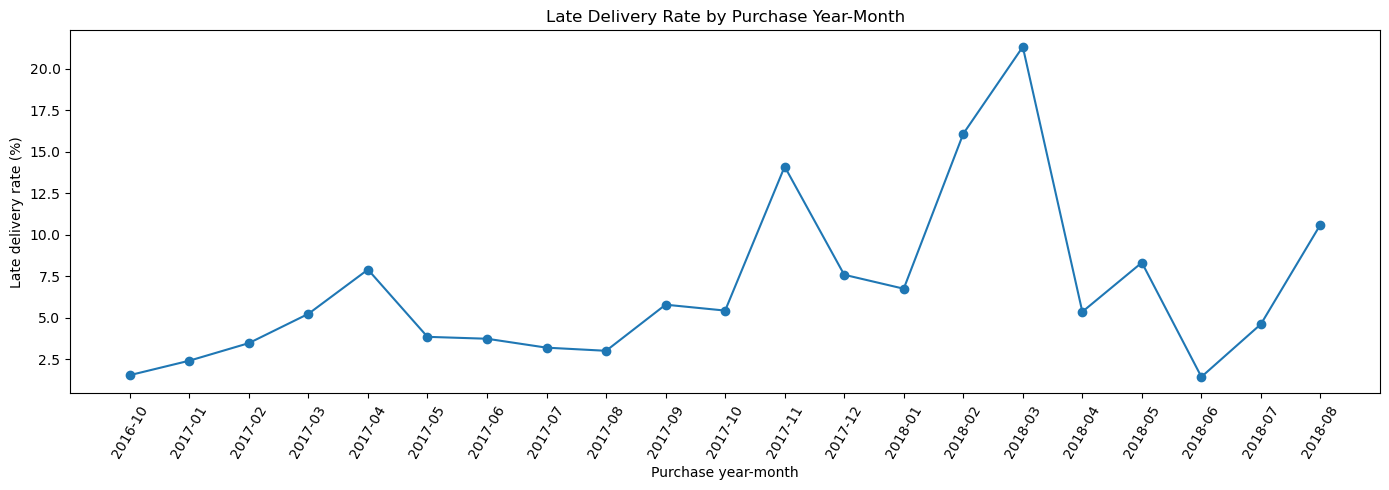

In [49]:
year_month_late_rate = (
    eda.groupby("eda_purchase_year_month", dropna=False)["late"]
    .agg(["count", "mean"])
)

year_month_late_rate["late_percentage"] = (
    year_month_late_rate["mean"] * 100
)

display(year_month_late_rate)
year_month_late_rate.to_csv(
    OUTPUT_DIR / "year_month_late_rate.csv"
)

plt.figure(figsize=(14, 5))
plt.plot(
    year_month_late_rate.index.astype(str),
    year_month_late_rate["late_percentage"],
    marker="o"
)
plt.xlabel("Purchase year-month")
plt.ylabel("Late delivery rate (%)")
plt.title("Late Delivery Rate by Purchase Year-Month")
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig(
    CHARTS_DIR / "late_rate_by_year_month.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


In [50]:
weekday_late_rate = (
    eda.groupby("eda_purchase_dayofweek")["late"]
    .agg(["count", "mean"])
)

weekday_late_rate["late_percentage"] = (
    weekday_late_rate["mean"] * 100
)

weekday_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_late_rate.index = [
    weekday_names[i]
    for i in weekday_late_rate.index
]

display(weekday_late_rate)

,count,mean,late_percentage
Monday,10979,0.0904,9.0445
Tuesday,10750,0.0857,8.5674
Wednesday,10639,0.0770,7.6981
Thursday,10016,0.0754,7.5379
Friday,9613,0.0849,8.4885
Saturday,7407,0.0751,7.5064
Sunday,8128,0.0762,7.6156


In [51]:
weekend_late_rate = (
    eda.groupby("eda_purchase_weekend")["late"]
    .agg(["count", "mean"])
)

weekend_late_rate["late_percentage"] = (
    weekend_late_rate["mean"] * 100
)

weekend_late_rate.index = [
    "Weekday" if not x else "Weekend"
    for x in weekend_late_rate.index
]

display(weekend_late_rate)

,count,mean,late_percentage
Weekday,51997,0.0828,8.2774
Weekend,15535,0.0756,7.5636


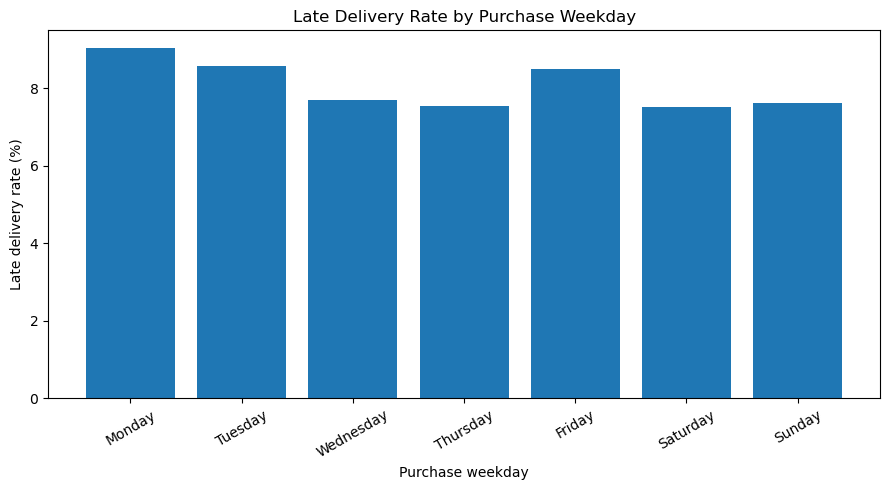

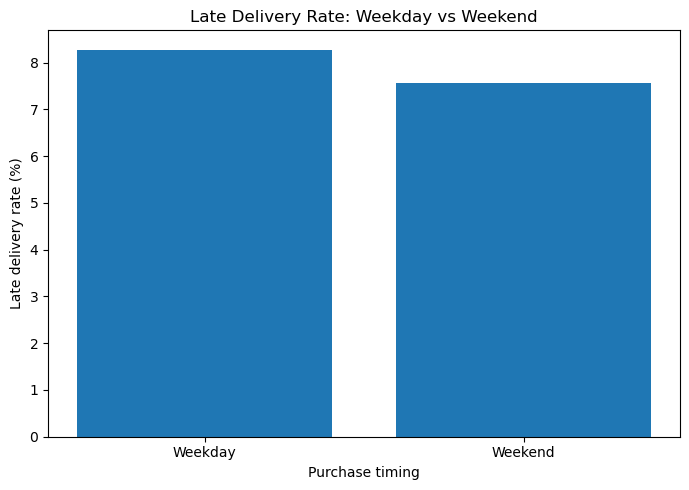

In [52]:
plt.figure(figsize=(9, 5))
plt.bar(weekday_late_rate.index, weekday_late_rate["late_percentage"])
plt.xlabel("Purchase weekday")
plt.ylabel("Late delivery rate (%)")
plt.title("Late Delivery Rate by Purchase Weekday")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "late_rate_by_weekday.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(weekend_late_rate.index, weekend_late_rate["late_percentage"])
plt.xlabel("Purchase timing")
plt.ylabel("Late delivery rate (%)")
plt.title("Late Delivery Rate: Weekday vs Weekend")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "late_rate_weekend_vs_weekday.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
hour_late_rate = (
    eda.groupby("eda_purchase_hour")["late"]
    .agg(["count", "mean"])
)

hour_late_rate["late_percentage"] = (
    hour_late_rate["mean"] * 100
)

display(hour_late_rate)

,count,mean,late_percentage
eda_purchase_hour,,,
0,1645,0.0906,9.0578
1,757,0.0845,8.4544
2,332,0.0723,7.2289
3,177,0.0452,4.5198
4,151,0.0464,4.6358
5,133,0.0677,6.7669
6,340,0.0853,8.5294
7,841,0.0820,8.2045
8,2056,0.0768,7.6848


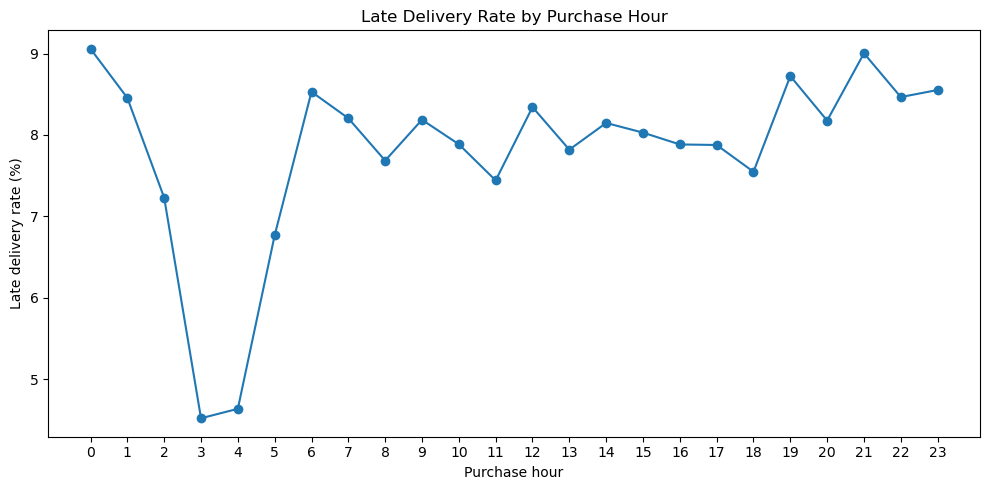

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(hour_late_rate.index, hour_late_rate["late_percentage"], marker="o")
plt.xlabel("Purchase hour")
plt.ylabel("Late delivery rate (%)")
plt.title("Late Delivery Rate by Purchase Hour")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig(CHARTS_DIR / "late_rate_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

In [55]:
estimated_window_summary = (
    eda["eda_estimated_lead_days"]
    .describe()
)

display(estimated_window_summary)

count   67,532.0000
mean        23.7369
std          8.7695
min          2.0080
25%         18.3254
50%         23.2245
75%         28.4189
max        155.1355
Name: eda_estimated_lead_days, dtype: float64

In [56]:
invalid_estimated_windows = (
    eda["eda_estimated_lead_days"] <= 0
).sum()

print(
    "Orders with non-positive estimated delivery window:",
    invalid_estimated_windows
)

Orders with non-positive estimated delivery window: 0


### Brazilian Holidays

Brazilian national holidays are analyzed as a temporal feature
during EDA.

Holiday information is considered for feature engineering in Notebook 05.

In [57]:
try:
    import holidays
except ImportError:
    raise ImportError(
        "Install the `holidays` package before running holiday analysis."
    )

years = eda["order_purchase_timestamp"].dt.year.dropna().unique()

brazil_holidays = holidays.Brazil(
    years=[int(y) for y in years]
)

eda["eda_is_holiday"] = (
    eda["order_purchase_timestamp"]
    .dt.date
    .isin(brazil_holidays)
)

holiday_late_rate = (
    eda.groupby("eda_is_holiday")["late"]
    .agg(["count", "mean"])
)

holiday_late_rate["late_percentage"] = (
    holiday_late_rate["mean"] * 100
)

holiday_late_rate.index = [
    "Non-Holiday" if not x else "Holiday"
    for x in holiday_late_rate.index
]

display(holiday_late_rate)

,count,mean,late_percentage
Non-Holiday,66502,0.0814,8.1411
Holiday,1030,0.0631,6.3107


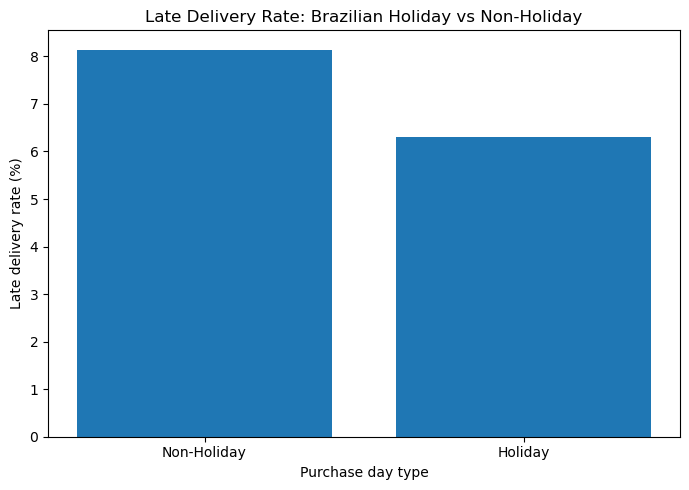

In [58]:
holiday_late_rate.to_csv(OUTPUT_DIR / "holiday_late_rate.csv")

plt.figure(figsize=(7, 5))
plt.bar(holiday_late_rate.index, holiday_late_rate["late_percentage"])
plt.xlabel("Purchase day type")
plt.ylabel("Late delivery rate (%)")
plt.title("Late Delivery Rate: Brazilian Holiday vs Non-Holiday")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "late_rate_holiday_vs_nonholiday.png", dpi=150, bbox_inches="tight")
plt.show()

In [59]:
eda["eda_purchase_to_carrier_days"] = (
    (
        eda["order_delivered_carrier_date"]
        - eda["order_purchase_timestamp"]
    ).dt.total_seconds()
    / 86400
)

eda["eda_carrier_to_customer_days"] = (
    (
        eda["order_delivered_customer_date"]
        - eda["order_delivered_carrier_date"]
    ).dt.total_seconds()
    / 86400
)

eda["eda_purchase_to_customer_days"] = (
    (
        eda["order_delivered_customer_date"]
        - eda["order_purchase_timestamp"]
    ).dt.total_seconds()
    / 86400
)

delivery_process_summary = eda[
    [
        "eda_purchase_to_carrier_days",
        "eda_carrier_to_customer_days",
        "eda_purchase_to_customer_days",
        "delivery_delay_days"
    ]
].describe().T

display(delivery_process_summary)

,count,mean,std,min,25%,50%,75%,max
eda_purchase_to_carrier_days,"67,531.0000",3.2235,3.5799,-171.2124,1.1293,2.2043,4.0602,66.0536
eda_carrier_to_customer_days,"67,531.0000",9.3160,8.6536,-16.0962,4.0937,7.0972,12.0267,205.1910
eda_purchase_to_customer_days,"67,532.0000",12.5402,9.4283,0.5334,6.7454,10.2161,15.6941,209.6286
delivery_delay_days,"67,532.0000",-11.1967,10.0801,-146.0161,-16.2374,-11.9731,-6.3892,188.9751


In [60]:
# Persist the main temporal/grouped EDA tables.
monthly_late_rate.to_csv(OUTPUT_DIR / "monthly_late_rate.csv")
year_month_late_rate.to_csv(OUTPUT_DIR / "year_month_late_rate.csv")
weekday_late_rate.to_csv(OUTPUT_DIR / "weekday_late_rate.csv")
weekend_late_rate.to_csv(OUTPUT_DIR / "weekend_late_rate.csv")
hour_late_rate.to_csv(OUTPUT_DIR / "hour_late_rate.csv")
estimated_window_summary.to_csv(OUTPUT_DIR / "estimated_delivery_window_summary.csv")
delivery_process_summary.to_csv(OUTPUT_DIR / "delivery_process_summary.csv")


## Leakage Audit

Target:

`late`

Excluded from predictive features:

- `delivery_delay_days`
- `label_data_available`
- `order_delivered_customer_date`
- `order_delivered_carrier_date`
- `order_status`
- `order_id`
- `customer_id`

Prediction point: **order approval time**.
Notebook 05 enforces this feature contract.

In [61]:
correlation_columns = NUMERICAL_COLUMNS + [
    "late"
]

correlation_matrix = (
    eda[correlation_columns]
    .corr(numeric_only=True)
)

display(correlation_matrix)

,item_count,total_price,total_freight_value,unique_products,unique_sellers,payment_count,total_payment_value,payment_types_count,late
item_count,1.0000,0.1555,0.4269,0.4714,0.2812,-0.0052,0.1910,-0.0074,-0.0190
total_price,0.1555,1.0000,0.4077,0.0598,0.0401,0.0020,0.9959,-0.0094,0.0151
total_freight_value,0.4269,0.4077,1.0000,0.1903,0.1231,0.0055,0.4888,-0.0027,0.0237
unique_products,0.4714,0.0598,0.1903,1.0000,0.5887,0.0054,0.0761,0.0030,-0.0233
unique_sellers,0.2812,0.0401,0.1231,0.5887,1.0000,0.0103,0.0507,0.0087,-0.0278
payment_count,-0.0052,0.0020,0.0055,0.0054,0.0103,1.0000,0.0025,0.5779,-0.0087
total_payment_value,0.1910,0.9959,0.4888,0.0761,0.0507,0.0025,1.0000,-0.0093,0.0167
payment_types_count,-0.0074,-0.0094,-0.0027,0.0030,0.0087,0.5779,-0.0093,1.0000,-0.0096
late,-0.0190,0.0151,0.0237,-0.0233,-0.0278,-0.0087,0.0167,-0.0096,1.0000


In [62]:
target_correlations = (
    correlation_matrix["late"]
    .drop("late")
    .sort_values()
)

display(target_correlations)

unique_sellers        -0.0278
unique_products       -0.0233
item_count            -0.0190
payment_types_count   -0.0096
payment_count         -0.0087
total_price            0.0151
total_payment_value    0.0167
total_freight_value    0.0237
Name: late, dtype: float64

In [63]:
target_correlations.to_csv(OUTPUT_DIR / "target_correlations.csv", header=["correlation"])
correlation_matrix.to_csv(OUTPUT_DIR / "correlation_matrix.csv")

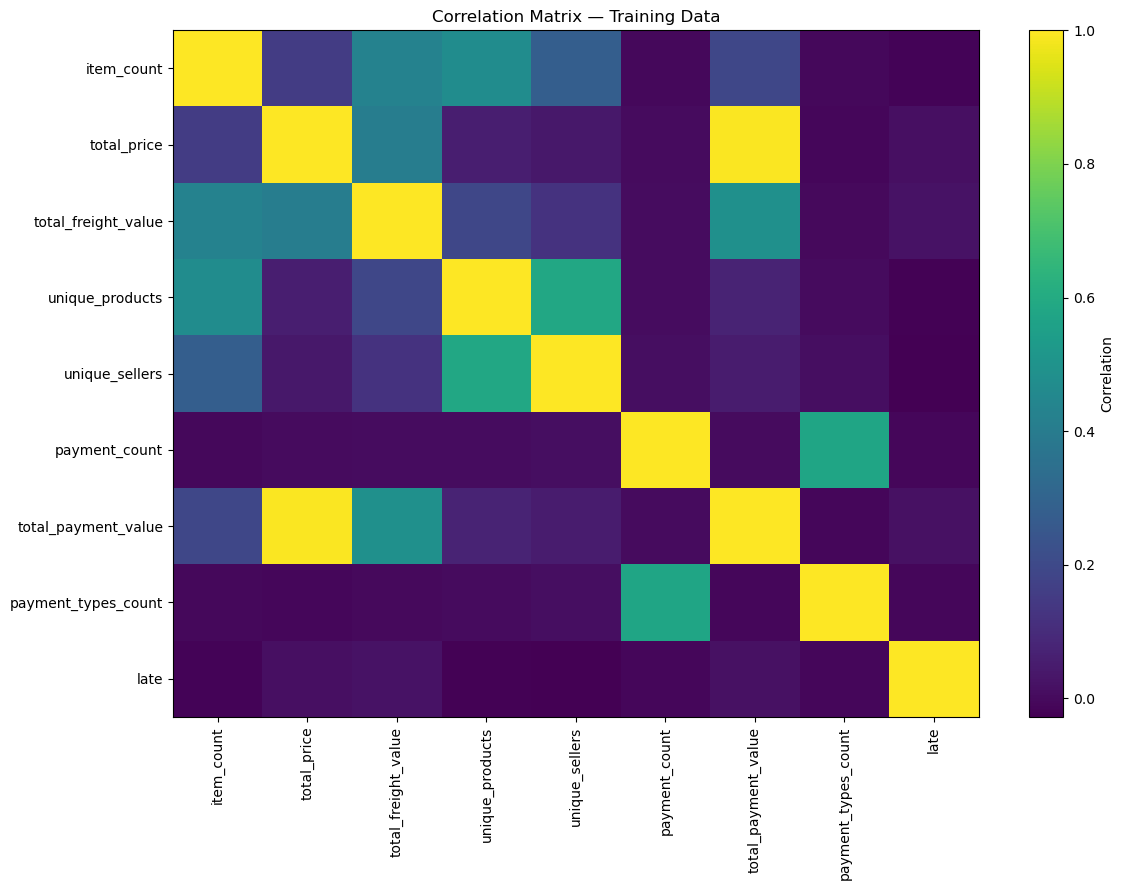

In [64]:
plt.figure(figsize=(12, 9))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Matrix — Training Data")
plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "correlation_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [65]:
item_count_target = (
    eda.groupby("item_count", dropna=False)["late"]
    .agg(["count", "mean"])
)

item_count_target["late_percentage"] = (
    item_count_target["mean"] * 100
)

display(item_count_target.head(20))

,count,mean,late_percentage
item_count,,,
1.0000,60832,0.0830,8.3016
2.0000,5133,0.0662,6.6238
3.0000,914,0.0558,5.5799
4.0000,346,0.0549,5.4913
5.0000,136,0.0515,5.1471
6.0000,134,0.0896,8.9552
7.0000,13,0.0000,0.0000
8.0000,5,0.0000,0.0000
9.0000,1,0.0000,0.0000


In [66]:
eda["eda_price_bin"] = pd.qcut(
    eda["total_price"],
    q=10,
    duplicates="drop"
)

price_late_rate = (
    eda.groupby("eda_price_bin", observed=True)["late"]
    .agg(["count", "mean"])
)

price_late_rate["late_percentage"] = (
    price_late_rate["mean"] * 100
)

display(price_late_rate)

,count,mean,late_percentage
eda_price_bin,,,
"(0.849, 25.4]",6756,0.0699,6.9864
"(25.4, 39.0]",6758,0.0738,7.3838
"(39.0, 50.0]",6752,0.0798,7.9828
"(50.0, 68.0]",6758,0.0821,8.2125
"(68.0, 86.99]",6769,0.0838,8.3764
"(86.99, 107.174]",6726,0.0755,7.5528
"(107.174, 134.34]",6753,0.0813,8.1297
"(134.34, 175.8]",6754,0.0888,8.8836
"(175.8, 269.0]",6753,0.0831,8.3074


In [67]:
eda["eda_estimated_window_bin"] = pd.qcut(
    eda["eda_estimated_lead_days"],
    q=10,
    duplicates="drop"
)

window_late_rate = (
    eda.groupby(
        "eda_estimated_window_bin",
        observed=True
    )["late"]
    .agg(["count", "mean"])
)

window_late_rate["late_percentage"] = (
    window_late_rate["mean"] * 100
)

display(window_late_rate)

,count,mean,late_percentage
eda_estimated_window_bin,,,
"(2.007, 13.049]",6754,0.1045,10.4531
"(13.049, 16.901]",6753,0.0666,6.6637
"(16.901, 19.433]",6753,0.0869,8.6924
"(19.433, 21.389]",6753,0.1060,10.6027
"(21.389, 23.224]",6753,0.0940,9.4032
"(23.224, 25.14]",6753,0.0851,8.5147
"(25.14, 27.246]",6753,0.0846,8.4555
"(27.246, 30.164]",6753,0.0748,7.4782
"(30.164, 34.286]",6753,0.0678,6.7822


In [68]:
item_count_target.to_csv(OUTPUT_DIR / "item_count_late_rate.csv")
price_late_rate.to_csv(OUTPUT_DIR / "price_quantile_late_rate.csv")
window_late_rate.to_csv(OUTPUT_DIR / "estimated_window_quantile_late_rate.csv")
state_late_rate.to_csv(OUTPUT_DIR / "state_late_rate.csv")

In [69]:
prediction_point = "order_approval"

ORIGINAL_FEATURE_COLUMNS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_estimated_delivery_date",
    "customer_city",
    "customer_state",
    "customer_zip_code_prefix",
    "item_count",
    "total_price",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "payment_count",
    "total_payment_value",
    "payment_types_count",
]

feature_availability = pd.DataFrame({"column": ORIGINAL_FEATURE_COLUMNS})
feature_availability["prediction_point"] = prediction_point
feature_availability["availability_status"] = "Needs confirmation"
feature_availability["availability_evidence"] = "Not established from order-level artifact"
feature_availability["candidate_status"] = "Candidate"
feature_availability["role"] = "Candidate"

feature_availability.loc[
    feature_availability["column"].isin([
        "order_purchase_timestamp",
        "order_approved_at",
        "order_estimated_delivery_date"
    ]), "role"
] = "Temporal candidate"

feature_availability.loc[
    feature_availability["column"].isin(CATEGORICAL_COLUMNS), "role"
] = "Categorical candidate"

feature_availability.loc[
    feature_availability["column"].isin(GEOGRAPHIC_COLUMNS), "role"
] = "Geographic candidate"

# Evidence-based availability decisions at the prediction point.
feature_availability.loc[
    feature_availability["column"] == "order_purchase_timestamp",
    ["availability_status", "availability_evidence", "candidate_status"]
] = ["Available", "Order event timestamp; available before approval", "Eligible"]

feature_availability.loc[
    feature_availability["column"] == "order_approved_at",
    ["availability_status", "availability_evidence", "candidate_status"]
] = ["Available at prediction point", "Prediction point itself", "Eligible"]

feature_availability.loc[
    feature_availability["column"] == "order_estimated_delivery_date",
    ["availability_status", "availability_evidence", "candidate_status"]
] = ["Expected available; verify source contract", "Promised/estimated delivery field in source artifact", "Conditional"]

for col in [
    "customer_city", "customer_state", "customer_zip_code_prefix",
    "item_count", "total_price", "total_freight_value",
    "unique_products", "unique_sellers", "payment_count",
    "total_payment_value", "payment_types_count"
]:
    feature_availability.loc[
        feature_availability["column"] == col,
        ["availability_status", "availability_evidence", "candidate_status"]
    ] = [
        "Present in training artifact; verify business-time availability",
        "Present in upstream order-level artifact; source event timing not documented here",
        "Conditional"
    ]

display(feature_availability)
feature_availability.to_csv(OUTPUT_DIR / "feature_availability_audit.csv", index=False)


,column,prediction_point,availability_status,availability_evidence,candidate_status,role
0,order_purchase_timestamp,order_approval,Available,Order event timestamp; available before approval,Eligible,Temporal candidate
1,order_approved_at,order_approval,Available at prediction point,Prediction point itself,Eligible,Temporal candidate
2,order_estimated_delivery_date,order_approval,Expected available; verify source contract,Promised/estimated delivery field in source ar...,Conditional,Temporal candidate
3,customer_city,order_approval,Present in training artifact; verify business-...,Present in upstream order-level artifact; sour...,Conditional,Categorical candidate
4,customer_state,order_approval,Present in training artifact; verify business-...,Present in upstream order-level artifact; sour...,Conditional,Categorical candidate
5,customer_zip_code_prefix,order_approval,Present in training artifact; verify business-...,Present in upstream order-level artifact; sour...,Conditional,Geographic candidate
6,item_count,order_approval,Present in training artifact; verify business-...,Present in upstream order-level artifact; sour...,Conditional,Candidate
7,total_price,order_approval,Present in training artifact; verify business-...,Present in upstream order-level artifact; sour...,Conditional,Candidate
8,total_freight_value,order_approval,Present in training artifact; verify business-...,Present in upstream order-level artifact; sour...,Conditional,Candidate
9,unique_products,order_approval,Present in training artifact; verify business-...,Present in upstream order-level artifact; sour...,Conditional,Candidate


In [70]:
feature_decisions = pd.DataFrame([
    ["order_id", "Exclude", "Identifier; no predictive meaning", "No"],
    ["customer_id", "Exclude", "High-cardinality identifier; memorization risk", "No"],
    ["late", "Target", "Prediction target", "N/A"],
    ["delivery_delay_days", "Exclude", "Directly derived from actual delivery outcome", "No"],
    ["label_data_available", "Exclude", "Label-availability indicator; future/outcome-related", "No"],
    ["order_delivered_customer_date", "Exclude", "Actual delivery timestamp; unavailable at prediction", "No"],
    ["order_delivered_carrier_date", "Exclude", "Post-prediction fulfillment timestamp", "No"],
    ["order_status", "Exclude", "Final order state; contains future process information", "No"],
    ["order_purchase_timestamp", "Engineer", "Extract calendar/time features; available before prediction", "Yes"],
    ["order_approved_at", "Engineer", "Prediction-point timestamp; derive approval-related timing", "Yes, at approval"],
    ["order_estimated_delivery_date", "Engineer", "Derive estimated lead/promised-window features", "Conditional: verify source contract"],
    ["customer_city", "Candidate", "Potential geographic signal; high cardinality", "Conditional"],
    ["customer_state", "Keep", "Compact geographic categorical feature", "Conditional"],
    ["customer_zip_code_prefix", "Candidate", "Geographic code; encode categorically or engineer region features", "Conditional"],
    ["item_count", "Candidate", "Order complexity; likely useful", "Conditional"],
    ["total_price", "Candidate", "Order value; may require robust transformation", "Conditional"],
    ["total_freight_value", "Candidate", "Shipping-cost signal", "Conditional"],
    ["unique_products", "Candidate", "Order/product complexity", "Conditional"],
    ["unique_sellers", "Candidate", "Multi-seller complexity", "Conditional"],
    ["payment_count", "Candidate", "Transaction complexity; confirm availability at prediction point", "Conditional"],
    ["total_payment_value", "Candidate", "Transaction value; confirm availability at prediction point", "Conditional"],
    ["payment_types_count", "Candidate", "Payment complexity; confirm availability at prediction point", "Conditional"],
], columns=["column", "decision", "reason", "availability_status"])

display(feature_decisions)
feature_decisions.to_csv(OUTPUT_DIR / "feature_decisions.csv", index=False)


,column,decision,reason,availability_status
0,order_id,Exclude,Identifier; no predictive meaning,No
1,customer_id,Exclude,High-cardinality identifier; memorization risk,No
2,late,Target,Prediction target,N/A
3,delivery_delay_days,Exclude,Directly derived from actual delivery outcome,No
4,label_data_available,Exclude,Label-availability indicator; future/outcome-r...,No
5,order_delivered_customer_date,Exclude,Actual delivery timestamp; unavailable at pred...,No
6,order_delivered_carrier_date,Exclude,Post-prediction fulfillment timestamp,No
7,order_status,Exclude,Final order state; contains future process inf...,No
8,order_purchase_timestamp,Engineer,Extract calendar/time features; available befo...,Yes
9,order_approved_at,Engineer,Prediction-point timestamp; derive approval-re...,"Yes, at approval"


## Modeling Recommendation

The target is imbalanced (~8.11% late deliveries), so accuracy
is not the primary metric.

### Models

- Dummy Classifier
- Logistic Regression
- Random Forest

### Primary Metric

- Average Precision (PR-AUC)

### Secondary Metrics

- Precision
- Recall
- F1-score
- ROC-AUC
- Accuracy

In [71]:
eda_summary = {
    "training_rows": len(eda),
    "training_columns": len(ORIGINAL_SOURCE_COLUMNS),
    "unique_orders": eda["order_id"].nunique(),
    "late_orders": int((eda["late"] == 1).sum()),
    "on_time_orders": int((eda["late"] == 0).sum()),
    "late_rate_pct": eda["late"].mean() * 100,
    "memory_mb": memory_usage_mb,
    "missing_columns": int((eda[ORIGINAL_SOURCE_COLUMNS].isna().sum() > 0).sum()),
    "numerical_columns": len(NUMERICAL_COLUMNS),
    "categorical_columns": len(CATEGORICAL_COLUMNS),
    "date_columns": len(DATE_COLUMNS),
    "seller_geography_available": False,
    "customer_seller_distance_available": False,
}

eda_summary_df = pd.DataFrame([eda_summary])
display(eda_summary_df)
eda_summary_df.to_csv(OUTPUT_DIR / "eda_summary.csv", index=False)


,training_rows,training_columns,unique_orders,late_orders,on_time_orders,late_rate_pct,memory_mb,missing_columns,numerical_columns,categorical_columns,date_columns,seller_geography_available,customer_seller_distance_available
0,67532,22,67532,5479,62053,8.1132,32.5464,2,8,3,5,False,False


# Final EDA Findings

- EDA uses training data only.
- Grain remains one row per order.
- `late` is imbalanced.
- Target-derived and post-outcome variables are excluded.
- Missingness and outliers are analyzed without automatic deletion.
- Categorical variables require appropriate encoding.
- Customer geography is available; seller geography is not.
- Prediction point: **order approval time**.
- Findings are used to design Notebook 05.

In [72]:
# Generate a data-driven findings report from the executed EDA results.
late_rate = eda["late"].mean() * 100

missing_lines = []
for _, r in missing_audit.iterrows():
    missing_lines.append(
        f"- {r['column']}: {int(r['missing_count'])} missing ({r['missing_pct']:.4f}%). "
        f"Late rate when missing = {r['late_rate_when_missing_pct']:.2f}%; "
        f"when observed = {r['late_rate_when_observed_pct']:.2f}%."
    )

if not missing_lines:
    missing_lines = ["- No missing values were observed in the training artifact."]

skewed = (
    numeric_summary[["skewness"]]
    .assign(abs_skew=lambda x: x["skewness"].abs())
    .sort_values("abs_skew", ascending=False)
    .head(5)
)
skew_lines = [
    f"- {idx}: skewness = {row['skewness']:.3f}"
    for idx, row in skewed.iterrows()
]

outlier_top = outlier_summary.sort_values("outlier_pct", ascending=False).head(5)
outlier_lines = [
    f"- {row['column']}: {int(row['outlier_count'])} IQR outliers ({row['outlier_pct']:.2f}%)."
    for _, row in outlier_top.iterrows()
]

rare_lines = []
for _, row in rare_summary.iterrows():
    rare_lines.append(
        f"- {row['column']}: {int(row['rare_categories'])} rare categories "
        f"({row['rare_percentage_of_categories']:.2f}% of categories), affecting "
        f"{int(row['rare_row_count']):,} rows ({row['rare_row_percentage']:.2f}%)."
    )

state_supported = state_late_rate[state_late_rate["count"] >= MIN_STATE_ORDERS]
state_lines = []
if not state_supported.empty:
    top_state = state_supported.iloc[0]
    low_state = state_supported.iloc[-1]
    state_lines = [
        f"- Highest supported state late rate: {state_supported.index[0]} = {top_state['late_percentage']:.2f}% (n={int(top_state['count'])}).",
        f"- Lowest supported state late rate: {state_supported.index[-1]} = {low_state['late_percentage']:.2f}% (n={int(low_state['count'])}).",
        "- State differences are descriptive associations, not causal effects."
    ]
else:
    state_lines = ["- No state met the minimum support threshold."]

# Strongest numerical target associations.
strong_corr = target_correlations.reindex(
    target_correlations.abs().sort_values(ascending=False).index
).head(5)
corr_lines = [
    f"- {idx}: Pearson r = {value:.3f}"
    for idx, value in strong_corr.items()
]

# Holiday comparison.
holiday_lines = []
if {"Holiday", "Non-Holiday"}.issubset(set(holiday_late_rate.index)):
    h = holiday_late_rate.loc["Holiday", "late_percentage"]
    nh = holiday_late_rate.loc["Non-Holiday", "late_percentage"]
    holiday_lines = [
        f"- Holiday late rate = {h:.2f}%; non-holiday late rate = {nh:.2f}%."
    ]
else:
    holiday_lines = ["- Holiday comparison was unavailable in the executed results."]

# Date consistency findings.
date_check_lines = [
    f"- {row['comparison']}: {int(row['invalid_rows'])} invalid rows "
    f"among {int(row['comparable_rows']):,} comparable rows "
    f"({row['invalid_pct_of_comparable']:.4f}%)."
    for _, row in date_order_checks.iterrows()
]

findings_text = f"""# Notebook 04 — EDA Findings

## Scope and methodology
- Source: `artifacts/notebook_03/train.parquet` only.
- Training rows: {len(eda):,}.
- Columns in original source artifact: {len(ORIGINAL_SOURCE_COLUMNS)}.
- Grain: one row per order.
- Prediction point used for feature-availability reasoning: **order approval time**.
- Validation and test sets were not opened.
- EDA helper columns were created in a separate `eda` working copy and are not part of the source artifact.

## Target
- On-time orders: {(eda['late'] == 0).sum():,}.
- Late orders: {(eda['late'] == 1).sum():,}.
- Late rate: {late_rate:.4f}%.
- Because the positive class is relatively small, accuracy must not be the sole model-selection metric.

## Missing values
{chr(10).join(missing_lines)}

Interpretation: missingness is treated as a data-availability signal until its source meaning and prediction-time availability are confirmed.

## Numerical variables
Top absolute skewness values observed:
{chr(10).join(skew_lines)}

Top IQR outlier rates observed:
{chr(10).join(outlier_lines)}

Numeric non-negativity checks were saved in `numeric_validity_summary.csv`; zero frequencies were saved in `zero_summary.csv`.
Outliers are not automatically removed; they require model-appropriate treatment or robust transformation if they are valid observations.

## Categorical variables
- `customer_state`: {eda['customer_state'].nunique()} categories.
- `customer_city`: {eda['customer_city'].nunique():,} categories.
- `customer_city` therefore requires a controlled encoding strategy rather than indiscriminate one-hot expansion.
- Rare-category impact:
{chr(10).join(rare_lines)}
- Formatting/collision audit was performed without automatically merging categories.

## Relationship with target
- Strongest numerical Pearson associations observed:
{chr(10).join(corr_lines)}
- Numerical group comparisons, categorical cross-tabs, state late rates, quantile analyses, and correlations were computed.
- Associations are descriptive; correlation or group differences do not establish causality.

## Geography
{chr(10).join(state_lines)}
- Available: customer state, customer city, customer ZIP-code prefix.
- Unavailable in the current order-level training artifact: seller state, seller ZIP, seller coordinates, and customer-seller distance.
- These unavailable seller features were not reconstructed in Notebook 04.

## Dates and delivery process
- Purchase month, year-month, weekday, weekend, hour, and Brazilian holiday associations were analyzed.
- Holiday result:
{chr(10).join(holiday_lines)}
- Date consistency checks:
{chr(10).join(date_check_lines)}
- Estimated delivery lead time was analyzed as a candidate predictive-time feature.
- Purchase-to-carrier, carrier-to-customer, purchase-to-customer, and delivery-delay durations were analyzed for diagnostics only.
- Post-outcome durations must not enter predictive features.

## Leakage exclusions
Excluded from predictive features:
- `order_id`, `customer_id`
- `delivery_delay_days`, `label_data_available`
- `order_delivered_carrier_date`, `order_delivered_customer_date`
- final `order_status`

## Feature-engineering direction for Notebook 05
- Engineer temporal features from purchase/approval timestamps.
- Engineer estimated delivery lead-time features.
- Encode `customer_state` and evaluate controlled treatment of high-cardinality city/ZIP.
- Verify business-time availability of payment and order-aggregate features before including them.
- Handle missing values explicitly, with missingness indicators only when justified by prediction-time availability.
- Preserve one-row-per-order grain.
- Fit preprocessing only on training data, then apply it unchanged to validation/test.

## Modeling direction
Start with a transparent baseline such as Logistic Regression and compare it with a nonlinear/tree-based model.
Use Precision, Recall, F1, PR-AUC and ROC-AUC; report the confusion matrix and accuracy as supplementary information.
"""

with open(OUTPUT_DIR / "eda_findings.md", "w", encoding="utf-8") as f:
    f.write(findings_text)

print("Saved:", OUTPUT_DIR / "eda_findings.md")
print("Finding report length:", len(findings_text), "characters")


Saved: ..\artifacts\notebook_04\eda_findings.md
Finding report length: 5367 characters


In [73]:
EDA_COLUMNS = [
    "order_id",
    "late",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_estimated_delivery_date",
    "customer_city",
    "customer_state",
    "customer_zip_code_prefix",
    "item_count",
    "total_price",
    "total_freight_value",
    "unique_products",
    "unique_sellers",
    "payment_count",
    "total_payment_value",
    "payment_types_count",
]

eda_data = train[EDA_COLUMNS].copy()

eda_data.to_parquet(
    OUTPUT_DIR / "eda_train_snapshot.parquet",
    index=False
)

print(
    "Saved EDA training snapshot:",
    OUTPUT_DIR / "eda_train_snapshot.parquet"
)
print("Snapshot shape:", eda_data.shape)


Saved EDA training snapshot: ..\artifacts\notebook_04\eda_train_snapshot.parquet
Snapshot shape: (67532, 16)


## Artifact Manifest

This notebook saves the EDA results, charts, training snapshot,
and findings used to guide feature engineering.

In [74]:
# Build the manifest after all other artifacts have been created.
manifest_path = OUTPUT_DIR / "artifact_manifest.csv"
if manifest_path.exists():
    manifest_path.unlink()

artifact_paths = sorted(OUTPUT_DIR.rglob("*"))
artifact_files = [p for p in artifact_paths if p.is_file()]

artifact_manifest = pd.DataFrame({
    "artifact": [str(p.relative_to(OUTPUT_DIR)) for p in artifact_files],
    "size_kb": [p.stat().st_size / 1024 for p in artifact_files]
})

# Write once, then refresh the manifest so it includes its own final size.
artifact_manifest.to_csv(manifest_path, index=False)

artifact_files = sorted([p for p in OUTPUT_DIR.rglob("*") if p.is_file()])
artifact_manifest = pd.DataFrame({
    "artifact": [str(p.relative_to(OUTPUT_DIR)) for p in artifact_files],
    "size_kb": [p.stat().st_size / 1024 for p in artifact_files]
})
artifact_manifest.to_csv(manifest_path, index=False)

display(artifact_manifest)
print(f"Total saved files: {len(artifact_manifest)}")


,artifact,size_kb
0,artifact_manifest.csv,2.9043
1,categorical_cleaning_audit.csv,0.2432
2,categorical_summary.csv,0.1562
3,categorical_target_rates.csv,158.1367
4,charts\boxplot_item_count.png,18.3418
5,charts\boxplot_payment_count.png,18.8564
6,charts\boxplot_payment_types_count.png,19.6475
7,charts\boxplot_total_freight_value.png,21.7793
8,charts\boxplot_total_payment_value.png,23.6348
9,charts\boxplot_total_price.png,19.9355


Total saved files: 67
